# EDA exhaustivo sobre **dev** · Ford FIC III

Exploración profunda de las tres tablas crudas y de la unión a nivel vehículo,
**restringida a los 290 vehículos de dev**. Es el paso previo a F2: acá se mira el
dato, no se construye el panel.

Cuatro cosas que conviene tener claras antes de leer un solo número:

1. **Esto no es F2.** `scripts/build_dataset.py` es todavía un
   `NotImplementedError`: no existe `panel.parquet` ni ninguna feature `feat_*` de
   ventana. Lo que hay son los seis CSV de `data/raw/` y la unión a nivel vehículo
   que dejó `scripts/make_test_split.py`. Acá **no** se define W, G, H ni Δ.
2. **El universo cambió, y esa es la novedad de esta versión.** De los 1081
   vehículos quedan **364**: 290 de dev y 74 de test. Los otros 717 están fuera del
   estudio porque su evento no se puede ubicar en el tiempo, o porque vienen de un
   mercado donde ningún evento es observable. El criterio, con su evidencia, está
   en §3.3; la decisión, en `docs/memoria/decisiones.md`.
3. **Todo sale del holdout congelado.** Los 74 vehículos de test no entran en
   ningún cómputo, ni siquiera para calcular una media. La guarda no es un
   comentario: después de armar cada tabla corre `check_dev_only()`, que falla
   ruidosamente si algo que no es de dev se coló (§0.2).
4. **La cohorte ES la etiqueta.** `IdentificationDate` nula ⇔ sin evento
   (`docs/memoria/f1-datos-reales.md`). Nunca entra como feature, y `cohort`
   tampoco.

Los datos los sirve `scripts/build_eda_cache.py`, que hace **una** pasada por los
crudos canonizando y filtrando a dev, y deja parquet reusables en
`experiments/eda/dev/`. El dashboard (`scripts/dashboard_eda.py`) lee exactamente
ese cache: el filtro dev se decide en un solo lugar.

> **Qué leer si ya leíste la versión anterior.** El universo pasó de 864 a 290
> vehículos y la tasa de eventos de 0,338 a 0,207. Las secciones que cambian de
> conclusión, no solo de número, son **§3.3** (el bloqueante de la fecha del evento
> está resuelto), **§3.4** (el evento ahora cae en un odómetro utilizable),
> **§7.3** (la alarma ya no es `daysUntilSale` sino `ProductionDay`, y aparece una
> colinealidad `Engine`↔`ModelSeries` que antes no se veía) y **§7.4** (el
> truncamiento ahora sí discrimina entre features predictivas y reactivas).

## Índice

| § | Qué contesta |
|---|---|
| 0 | Setup, holdout y la guarda dev-only |
| 1 | Diccionario de datos: CSV real vs. `raw_sources.yaml` vs. PDF oficial |
| 2 | Estáticas y los sesgos de muestreo que sobreviven al recorte |
| 3 | Universo del estudio, etiqueta, anclaje temporal y supervivencia |
| 4 | Calidad del eje de odómetro |
| 5 | Uso y contexto (`trips`) |
| 6 | Severidad y postratamiento (`signals` + las dos columnas nuevas) |
| 7 | Correlaciones, truncamiento y diagnóstico para feature engineering |
| 8 | Análisis temporal |
| 9 | Factibilidad de las features del plan §4 |
| 10 | Síntesis para quien implemente F2 |

> **Leer antes que nada (2026-09-18).** Este notebook se revisó entero al construir el panel de F2. Se sostiene casi todo, con tres correcciones que están marcadas en el lugar donde aplican: (1) `regen_per_1000km` no es señal, es el marcador `Regenerations` cortado el 25-05-2026 (§6.2, §6.3, §7.4); (2) la escala de `AirRegeneration`/`Acumulation` es 0–100, no 0–95 (§6.4); (3) el 35% de las filas de `trips` son idle de 0 km, y `KilometerPerHour` es nulo exactamente ahí (§4, §5). Lo que faltaba medir (factibilidad de W/G/H, perfil alineado al evento, confusor calendario, `daysUntilSale` como exposición) está en `scripts/eda_gaps.py` y en [`docs/memoria/f2-eda-revision-y-features.md`](../docs/memoria/f2-eda-revision-y-features.md), que es la versión vigente. Las celdas no se re-ejecutaron.

## 0 · Setup

### 0.1 · Qué se carga y de dónde

Nada de paths a mano: todo pasa por `src/config.py` (`load_config`,
`resolve_path`). El universo de dev sale de `data/processed/test_split.json`
—congelado el 2026-09-16, semilla 42— y los datos del cache dev-only.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from scipy.stats import mannwhitneyu, spearmanr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from src.config import load_config, resolve_path, set_seed
from src.data.dedupe import canonical_map
from src.data.loader import load_sources_config
from src.eval.splits import load_test_split
from scripts.build_eda_cache import (
    ALERT_RED,
    BLUE,
    CATEGORICAL,
    COHORT_COLORS,
    COHORT_LABELS,
    FORD_BLUE,
    INK,
    SEQUENTIAL,
    MISSING_FAMILIES,
    PDF_COLUMNS,
    cache_dir,
    cache_exists,
    dictionary_comparison,
    feature_feasibility,
    load_eda_cache,
    raw_columns,
    vehicle_matrix,
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)

CONFIG = "configs/data/eda_cache.yaml"
cfg = load_config(CONFIG)
set_seed(int(cfg["seed"]))

split = load_test_split(cfg["test_split"])
DEV_VEHICLES = set(split["dev_vehicles"])
TEST_VEHICLES = set(split["test_vehicles"])
CLONES = canonical_map(cfg["dedupe"])

print(f"holdout congelado el {split['created_at']} (semilla {split['seed']})")
print(f"dev : {len(DEV_VEHICLES):>5} vehículos  ({split['dev']['n_event_vehicles']} con evento, "
      f"tasa {split['dev']['event_rate']:.4f})")
print(f"test: {len(TEST_VEHICLES):>5} vehículos  -> NO se tocan en todo el notebook")
print(f"clones canonizados: {len(CLONES)} códigos -> {len(set(CLONES.values()))} vehículos")

holdout congelado el 2026-09-17T23:09:36+00:00 (semilla 42)
dev :   290 vehículos  (60 con evento, tasa 0.2069)
test:    74 vehículos  -> NO se tocan en todo el notebook
clones canonizados: 13 códigos -> 13 vehículos


### 0.2 · La guarda dev-only

`test_split.json` guarda **tres** listas de `vehicle_id` ya canónicos: `dev` (290),
`test` (74) y `excluded` (717, fuera del universo del estudio). El EDA corre sobre
la primera y nada más.

Que sean tres y no dos cambia la guarda. Antes alcanzaba con verificar *ausencia de
test*, porque dev era el complemento; ahora un vehículo excluido no es de test
**pero tampoco es de dev**, así que el chequeo tiene que ser de **pertenencia**:

```python
fuera = set(tabla["vehicle_id"]) - DEV_VEHICLES   # ni test, ni excluidos, ni forasteros
```

Y el orden del filtro sobre los crudos sigue sin ser negociable, porque los CSV
todavía traen los 26 `VehicleCode` sin canonizar:

```python
chunk["VehicleCode"] = chunk["VehicleCode"].replace(mapping)   # 1) canonizar
chunk_dev = chunk[chunk["VehicleCode"].isin(dev_vehicles)]      # 2) recién ahí, dev
```

Al revés, las filas del código clon descartado (`VEH_0345`) no matchean ninguna id
de la lista —que solo tiene `VEH_0344`— y desaparecen sin ruido. No es leakage,
pero sí un error de conteo invisible.

Eso ya lo hace `scripts/build_eda_cache.py` (`assert_dev_only`). Lo que hace este
notebook es **verificarlo**, tabla por tabla.

In [2]:
def check_dev_only(frame: pd.DataFrame, nombre: str, *, id_col: str = "vehicle_id") -> pd.DataFrame:
    '''Falla ruidosamente si alguna fila de test se coló. Devuelve la tabla para encadenar.'''
    if id_col not in frame.columns:
        raise KeyError(f"`{nombre}` no tiene `{id_col}`: la guarda no se puede verificar")
    ids = set(frame[id_col].astype(str).unique())
    intrusos = ids & TEST_VEHICLES
    assert not intrusos, (
        f"`{nombre}`: {len(intrusos)} vehículo(s) de TEST en una tabla de dev "
        f"(ej.: {sorted(intrusos)[:3]})"
    )
    fuera = ids - DEV_VEHICLES
    assert not fuera, f"`{nombre}`: {len(fuera)} vehículo(s) fuera del universo de dev"
    print(f"  [ok] {nombre:<24} {len(frame):>8} filas · {len(ids):>4} vehículos · 0 de test")
    return frame


if not cache_exists(CONFIG):
    raise SystemExit(
        "No hay cache del EDA. Construilo con:\n"
        "    python scripts/build_eda_cache.py --config configs/data/eda_cache.yaml"
    )

cache = load_eda_cache(CONFIG)
META = cache["meta"]

print("Guarda dev-only sobre cada tabla del cache:")
for nombre, tabla in cache.items():
    if isinstance(tabla, pd.DataFrame) and "vehicle_id" in tabla.columns:
        check_dev_only(tabla, nombre)

Guarda dev-only sobre cada tabla del cache:
  [ok] vehicles_dev                  290 filas ·  290 vehículos · 0 de test
  [ok] trips_agg_dev                 290 filas ·  290 vehículos · 0 de test
  [ok] signals_agg_dev               290 filas ·  290 vehículos · 0 de test
  [ok] severity_scopes_dev           870 filas ·  290 vehículos · 0 de test
  [ok] message_counts_dev           3003 filas ·  290 vehículos · 0 de test
  [ok] airfilter_counts_dev         1634 filas ·  290 vehículos · 0 de test
  [ok] trips_sample_dev           250000 filas ·  290 vehículos · 0 de test
  [ok] signals_sample_dev         250000 filas ·  290 vehículos · 0 de test
  [ok] probe_trips_dev             14462 filas ·    8 vehículos · 0 de test
  [ok] probe_signals_dev           57945 filas ·    8 vehículos · 0 de test


In [3]:
# La tabla sobre la que corre casi todo el notebook: una fila por vehículo de dev,
# con las estáticas, la etiqueta y todos los agregados de `trips` y `signals`.
veh = check_dev_only(vehicle_matrix(cache), "vehicle_matrix")

print(f"\n{veh.shape[0]} vehículos x {veh.shape[1]} columnas")
print(f"con evento: {int(veh['event_observed'].sum())} · tasa {veh['event_observed'].mean():.4f}")
print(f"\ncache construido el {META['created_at']} · semilla {META['seed']} · alcance {META['scope']}")
veh[["vehicle_id", "event_observed", "static_Engine", "static_ModelSeries", "n_trips", "n_signals", "trip_odo_max"]].head(3)

  [ok] vehicle_matrix                290 filas ·  290 vehículos · 0 de test

290 vehículos x 95 columnas
con evento: 60 · tasa 0.2069

cache construido el 2026-09-17T23:11:27+00:00 · semilla 42 · alcance dev-only


,vehicle_id,event_observed,static_Engine,static_ModelSeries,n_trips,n_signals,trip_odo_max
0,VEH_0046,0,ENG_1,MODEL_4,1920,7661,40790.0
1,VEH_0048,0,ENG_1,MODEL_4,2646,9733,46197.0
2,VEH_0050,0,ENG_1,MODEL_4,1758,5579,17955.0


### 0.3 · Estilo de las figuras

Paleta anclada al azul Ford de `src/eval/plots.py` (`#1c3f94`). Como marca de
datos se usa el escalón `#2c52a8`, que es el del mismo tono dentro de la banda de
luminosidad que exige el validador de paletas; el `#1c3f94` de marca queda para
tinta de títulos. El rojo es el `ALERT_RED` del repo.

La paleta pasa los seis chequeos del validador (peor par adyacente: ΔE 9,1 bajo
simulación de daltonismo, 19,6 en visión normal). Casi todo el EDA tiene **dos**
series —la cohorte es la etiqueta—, así que el par azul/rojo es el caso normal y
siempre lleva leyenda.

In [4]:
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK["muted"],
    "axes.labelcolor": INK["secondary"],
    "axes.titlecolor": INK["primary"],
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": INK["grid"],
    "grid.linewidth": 0.7,
    "xtick.color": INK["muted"],
    "ytick.color": INK["muted"],
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "legend.fontsize": 8,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "figure.dpi": 110,
    "savefig.dpi": 110,
})
sns.set_palette(list(CATEGORICAL))

COHORT_ORDER = [0, 1]


def cohort_hist(ax, hist, metric, *, titulo=None, xlabel=None, logy=False):
    '''Histograma EXACTO por cohorte (frecuencia relativa, no conteo: los grupos difieren).'''
    data = hist[hist["metric"].eq(metric)]
    for flag in COHORT_ORDER:
        side = data[data["event_observed"].eq(flag)]
        if side.empty:
            continue
        centro = (side["bin_left"] + side["bin_right"]) / 2
        ax.step(centro, side["frac"], where="mid", color=COHORT_COLORS[flag], lw=2,
                label=COHORT_LABELS[flag])
        ax.fill_between(centro, side["frac"], step="mid", color=COHORT_COLORS[flag], alpha=0.12)
    ax.set_title(titulo or metric)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel("fracción de viajes")
    if logy:
        ax.set_yscale("log")
    ax.legend(loc="upper right")
    return ax


def cohort_box(ax, frame, column, *, titulo=None, ylabel=None, logy=False, showfliers=False):
    '''Boxplot por cohorte de un agregado **por vehículo** (un punto = un vehículo).'''
    grupos = [frame.loc[frame["event_observed"].eq(f), column].dropna().to_numpy() for f in COHORT_ORDER]
    bp = ax.boxplot(grupos, patch_artist=True, widths=0.55, showfliers=showfliers,
                    medianprops={"color": "white", "lw": 1.6},
                    flierprops={"marker": ".", "ms": 3, "alpha": 0.3, "mec": INK["muted"]})
    for parche, flag in zip(bp["boxes"], COHORT_ORDER):
        parche.set_facecolor(COHORT_COLORS[flag])
        parche.set_edgecolor("white")
        parche.set_linewidth(1.2)
    for llave in ("whiskers", "caps"):
        for artista in bp[llave]:
            artista.set_color(INK["muted"])
    ax.set_xticks([1, 2], [f"{COHORT_LABELS[f]}\n(n={len(g)})" for f, g in zip(COHORT_ORDER, grupos)])
    ax.set_title(titulo or column)
    ax.set_ylabel(ylabel or "")
    if logy:
        ax.set_yscale("symlog", linthresh=1e-3)
    return ax


def compara_cohortes(frame, columnas):
    '''Mediana por cohorte + Mann-Whitney. Descriptivo: sin corrección por multiplicidad.'''
    filas = []
    for col in columnas:
        a = frame.loc[frame["event_observed"].eq(0), col].dropna()
        b = frame.loc[frame["event_observed"].eq(1), col].dropna()
        if len(a) < 20 or len(b) < 20:
            continue
        u, p = mannwhitneyu(b, a, alternative="two-sided")
        filas.append({
            "variable": col,
            "mediana_sanos": a.median(),
            "mediana_evento": b.median(),
            "ratio": b.median() / a.median() if a.median() else np.nan,
            # Tamaño de efecto = probabilidad de que un vehículo con evento supere a
            # uno sano (0,5 = sin diferencia). Más informativo que el p-valor con n=864.
            "prob_supera": u / (len(a) * len(b)),
            "p_mannwhitney": p,
        })
    return pd.DataFrame(filas).sort_values("prob_supera", key=lambda s: (s - 0.5).abs(), ascending=False)


print("estilo listo ·", len(CATEGORICAL), "slots categóricos · cohorte =", COHORT_COLORS)

estilo listo · 8 slots categóricos · cohorte = {0: '#2c52a8', 1: '#c0392b'}


## 1 · Diccionario de datos: real vs. declarado vs. oficial

Tres fuentes que deberían decir lo mismo y no lo dicen:

- **el PDF oficial** de Ford (`data/raw/FIC_III___Data_Driven_Powertrain_Intelligence (2).pdf`,
  anexos 7.1 / 7.2 / 7.3): 40 columnas en `TripSummary`, 7 en `DynamicInformation`,
  7 en `VehicleGeneralInformation`;
- **`configs/data/raw_sources.yaml`**: el contrato del repo, auditado en F1 contra
  los archivos reales;
- **el CSV**: lo que hay.

El PDF avisa en §4.2 que las variables vienen *"renombradas y, de corresponder,
anonimizadas"*, así que una diferencia de nombre no es necesariamente una columna
faltante. Lo que sigue separa las tres cosas: renombrada, ausente, o presente sin
estar documentada.

In [5]:
# El diccionario oficial está transcripto en `scripts/build_eda_cache.py`
# (`PDF_COLUMNS`): el PDF no es legible por código, y escribirlo una sola vez evita
# que el notebook y el dashboard digan cosas distintas.
fuentes = load_sources_config(cfg["sources"])
diccionario = dictionary_comparison(CONFIG)

print("Columnas reales de cada CSV:")
for tabla, columnas in raw_columns(CONFIG).items():
    print(f"  {tabla:<9} {len(columnas):>3} columnas   (el PDF declara {len(PDF_COLUMNS[tabla])})")

print()
print(diccionario.groupby(["tabla", "estado"]).size().unstack(fill_value=0).to_string())

Columnas reales de cada CSV:
  vehicles    7 columnas   (el PDF declara 7)
  trips      25 columnas   (el PDF declara 40)
  signals     7 columnas   (el PDF declara 7)

estado    documentada y AUSENTE  documentada y presente  presente SIN documentar
tabla                                                                           
signals                       0                       7                        0
trips                        19                      21                        4
vehicles                      0                       7                        0


In [6]:
# El detalle que importa: qué prometió el PDF y no está en ningún archivo.
ausentes = diccionario[diccionario["estado"].eq("documentada y AUSENTE")]
print(f"Columnas del diccionario oficial que NO existen en los CSV: {len(ausentes)}\n")
resumen = pd.DataFrame([
    {"familia": familia, "n_columnas": len(cols),
     "todas_ausentes": set(cols).issubset(set(ausentes["columna"])), "columnas": ", ".join(cols)}
    for familia, cols in MISSING_FAMILIES.items()
])
print(resumen.to_string(index=False))

Columnas del diccionario oficial que NO existen en los CSV: 19

                      familia  n_columnas  todas_ausentes                                                                                                                                                       columnas
                          GPS           4            True                                                                   VehicleGPSLatDataStart, VehicleGPSLatDataEnd, VehicleGPSLongDataStart, VehicleGPSLongDataEnd
                    elevación           2            True                                                                                                           VehicleElevationRangeStart, VehicleElevationRangeEnd
        presión de neumáticos           8            True TirePressureLFStart, TirePressureLFEnd, TirePressureRFStart, TirePressureRFEnd, TirePressureLRStart, TirePressureLREnd, TirePressureRRStart, TirePressureRREnd
         DPF (por ese nombre)           2            True           

In [7]:
# Y al revés: columnas del CSV que el diccionario oficial no menciona bajo ningún nombre.
sin_documentar = diccionario[diccionario["estado"].eq("presente SIN documentar")]
print("Columnas presentes en los CSV y ausentes del diccionario oficial:")
print(sin_documentar[["tabla", "columna", "en_raw_sources"]].to_string(index=False))
print("\n`cohort` no cuenta: la agrega el loader a partir del archivo del que salió la fila.")
print("Las cuatro de `trips` se caracterizan en §6.4 — y ahí deja de ser un misterio.")

Columnas presentes en los CSV y ausentes del diccionario oficial:
tabla              columna  en_raw_sources
trips         AirFilterEnd            True
trips       AirFilterStart            True
trips   AirRegenerationEnd            True
trips AirRegenerationStart            True

`cohort` no cuenta: la agrega el loader a partir del archivo del que salió la fila.
Las cuatro de `trips` se caracterizan en §6.4 — y ahí deja de ser un misterio.


**Qué queda establecido en esta sección**

- `trips` real tiene **25 columnas**, no las 40 del anexo 7.1. Faltan, bajo
  cualquier nombre: las 4 de GPS, las 2 de elevación, las 8 de presión de
  neumáticos, `FuelLvlAutonomyStart` y las 2 de hollín de regeneración manual.
- Faltan también `DieselParticulateFilterStart/End` **bajo ese nombre**. Ojo con
  la conclusión rápida: §6.4 muestra que el dato sí está, con otro nombre.
- Aparecen 4 columnas que el diccionario no menciona: `AirFilterStart/End`
  (categóricas) y `AirRegenerationStart/End` (numéricas). Son exactamente las que
  §6.4 identifica.
- `signals` y `vehicles` cierran con el anexo salvo por renombres cosméticos
  (`Vin`→`VehicleCode`, `EventTimestamp`→`eventTimestamp`,
  `SalesCountryCd`→`SalesCountry_cd`).

La traducción a features del plan §4 está en §9.

## 2 · Estáticas

Las cinco `static_*` del contrato: `Engine`, `ModelSeries`, `SalesCountry_cd`,
`daysUntilSale` y `ProductionDay`. Las tres primeras son categóricas; las dos
últimas, días.

Todo lo de esta sección es **sobre los 290 de dev**. Los números de `docs/memoria/`
anteriores al recorte están medidos sobre los 1081 o sobre los 864 de dev viejo, así
que acá **no tienen por qué coincidir**: lo que interesa es si el hallazgo
cualitativo sobrevive, no si el decimal se repite.

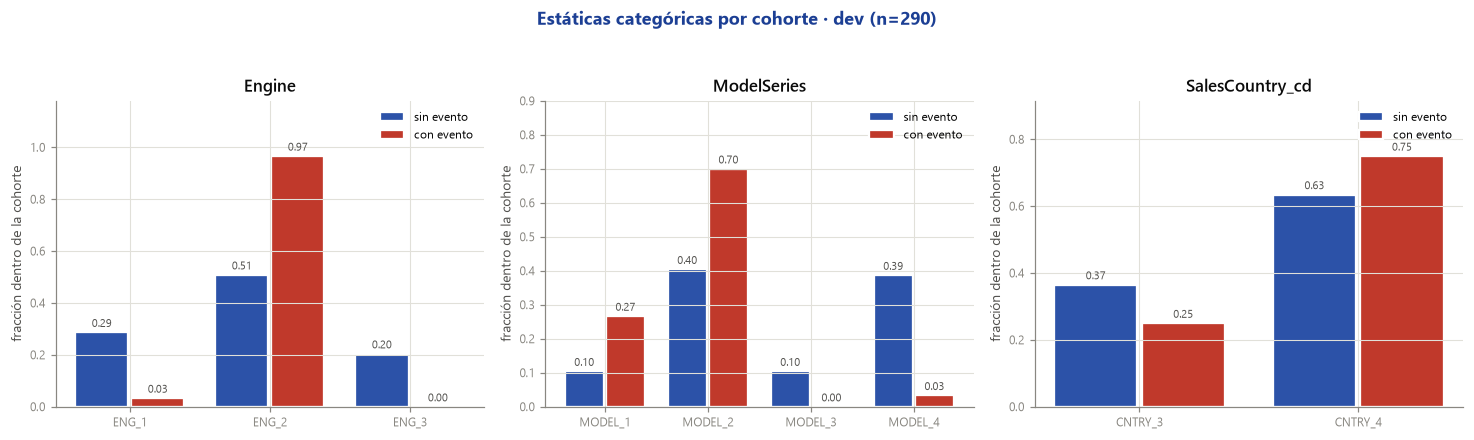

In [8]:
CATEGORICAS = ["static_Engine", "static_ModelSeries", "static_SalesCountry_cd"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, columna in zip(axes, CATEGORICAS):
    tabla = pd.crosstab(veh[columna], veh["event_observed"])
    frac = tabla / tabla.sum()
    x = np.arange(len(frac))
    ancho = 0.38
    for i, flag in enumerate(COHORT_ORDER):
        if flag not in frac.columns:
            continue
        barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), frac[flag], ancho,
                        color=COHORT_COLORS[flag], label=COHORT_LABELS[flag],
                        edgecolor="white", linewidth=1.5)
        ax.bar_label(barras, fmt="%.2f", fontsize=7, color=INK["secondary"], padding=2)
    ax.set_xticks(x, frac.index, rotation=0)
    ax.set_title(columna.replace("static_", ""))
    ax.set_ylabel("fracción dentro de la cohorte")
    ax.set_ylim(0, max(0.9, frac.to_numpy().max() * 1.22))
    ax.legend(loc="upper right")
fig.suptitle(f"Estáticas categóricas por cohorte · dev (n={len(veh)})", y=1.04, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [9]:
# El sesgo de ENG_3 (docs/memoria/f1-sesgo-eng3.md), recontado dentro de dev.
motor = pd.crosstab(veh["static_Engine"], veh["event_observed"])
motor.columns = ["sanos", "con_evento"]
motor = motor.assign(
    frac_sanos=lambda d: d["sanos"] / d["sanos"].sum(),
    frac_con_evento=lambda d: d["con_evento"] / d["con_evento"].sum(),
    tasa_de_eventos=lambda d: d["con_evento"] / (d["sanos"] + d["con_evento"]),
)
print("ENG_3 en dev: %d vehículos sanos, %d con evento" %
      (int(motor.loc["ENG_3", "sanos"]), int(motor.loc["ENG_3", "con_evento"])))
print("(sobre los 1081 sin recortar el doc reporta 268 sanos y 0 con evento:\n el recorte baja el volumen, no cambia el hecho)\n")
motor.round(4)

ENG_3 en dev: 47 vehículos sanos, 0 con evento
(sobre los 1081 sin recortar el doc reporta 268 sanos y 0 con evento:
 el recorte baja el volumen, no cambia el hecho)



,sanos,con_evento,frac_sanos,frac_con_evento,tasa_de_eventos
static_Engine,,,,,
ENG_1,66,2,0.2870,0.0333,0.0294
ENG_2,117,58,0.5087,0.9667,0.3314
ENG_3,47,0,0.2043,0.0000,0.0000


**El sesgo se sostiene, y encima se agrava.** `ENG_3` son 47 vehículos sanos y
**cero** con evento: la regla `Engine == ENG_3 ⇒ sano` sigue acertando el 100% de
las veces adentro de este dataset y ninguna afuera. Por eso `Engine` está en
`features.static_excluded` de `configs/data/panel_v1.yaml` y **no entra al
modelo**.

**Lo que sí cambia respecto de la versión anterior del EDA: `ModelSeries` ya no
está limpio.** Antes se podía decir que aparecía en las dos cohortes con
proporciones comparables. En el universo recortado, `MODEL_3` tiene 24 vehículos y
**0 eventos**, y `MODEL_4` tiene 91 y **2** (tasa 0,022) contra 0,400 de `MODEL_1`
y 0,311 de `MODEL_2`.

Y no es una coincidencia: el cruce `Engine × ModelSeries` es casi diagonal, así
que **sacar `Engine` y dejar `ModelSeries` no saca el sesgo, solo lo renombra**.
La celda de abajo lo muestra.

In [10]:
# ¿Sacar `Engine` alcanza? El cruce con `ModelSeries` dice que no.
cruce = pd.crosstab(veh["static_Engine"], veh["static_ModelSeries"])
print("Engine x ModelSeries (vehículos de dev):")
print(cruce.to_string())

celdas = (veh.groupby(["static_Engine", "static_ModelSeries"], observed=True)["event_observed"]
          .agg(vehiculos="size", con_evento="sum"))
celdas["tasa"] = (celdas["con_evento"] / celdas["vehiculos"]).round(3)
print("\nTasa de eventos por celda ocupada:")
print(celdas[celdas["vehiculos"] > 0].to_string())

ocupadas = int((cruce > 0).sum().sum())
print(f"\nCeldas ocupadas: {ocupadas} de {cruce.shape[0] * cruce.shape[1]} posibles.")
print("Cada motor vive en 1 o 2 modelos y casi ningún modelo mezcla motores:")
print("las dos columnas son, a efectos prácticos, la misma partición de la flota.")

Engine x ModelSeries (vehículos de dev):
static_ModelSeries  MODEL_1  MODEL_2  MODEL_3  MODEL_4
static_Engine                                         
ENG_1                     0        0        0       68
ENG_2                    40      135        0        0
ENG_3                     0        0       24       23

Tasa de eventos por celda ocupada:
                                  vehiculos  con_evento   tasa
static_Engine static_ModelSeries                              
ENG_1         MODEL_4                    68           2  0.029
ENG_2         MODEL_1                    40          16  0.400
              MODEL_2                   135          42  0.311
ENG_3         MODEL_3                    24           0  0.000
              MODEL_4                    23           0  0.000

Celdas ocupadas: 5 de 12 posibles.
Cada motor vive en 1 o 2 modelos y casi ningún modelo mezcla motores:
las dos columnas son, a efectos prácticos, la misma partición de la flota.


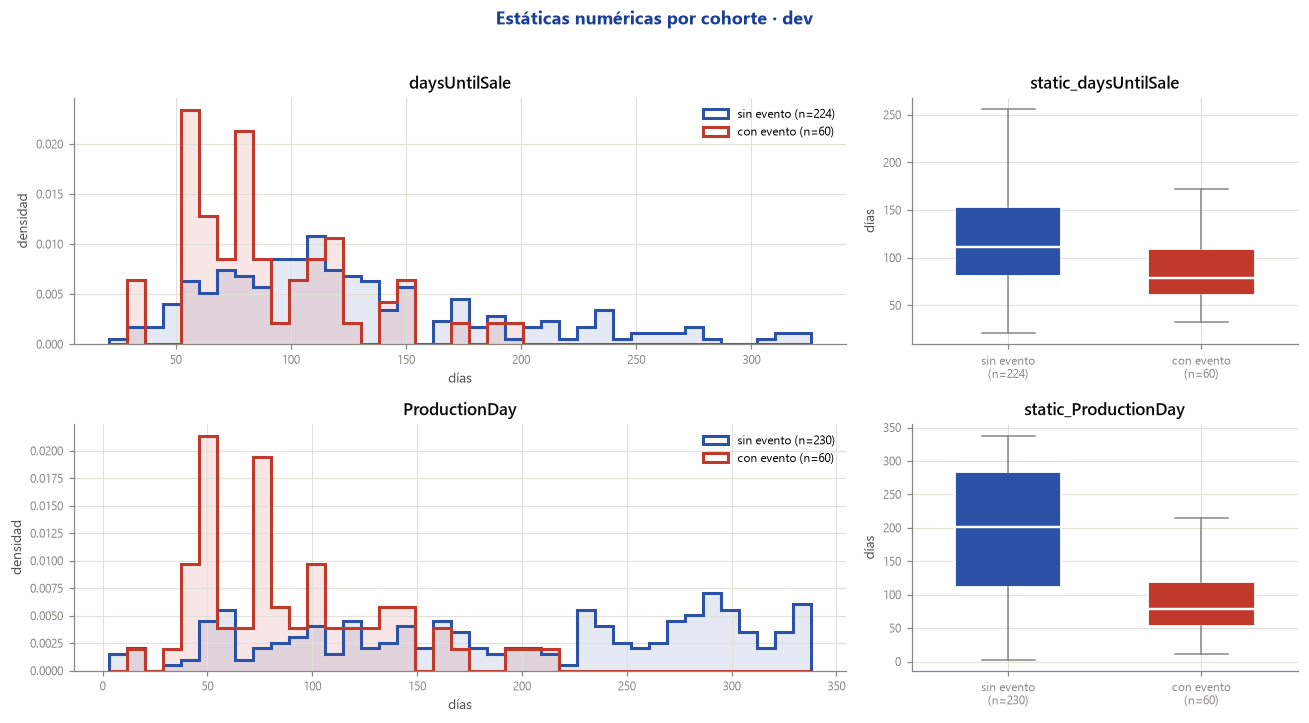

,variable,mediana_sanos,mediana_evento,ratio,prob_supera,p_mannwhitney
1,static_ProductionDay,200.5,79.0,0.3940,0.1899,0.0
0,static_daysUntilSale,111.0,79.0,0.7117,0.3153,0.0


In [11]:
NUMERICAS_ESTATICAS = ["static_daysUntilSale", "static_ProductionDay"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), gridspec_kw={"width_ratios": [2, 1]})
for fila, columna in enumerate(NUMERICAS_ESTATICAS):
    ax = axes[fila, 0]
    bins = np.linspace(veh[columna].min(), veh[columna].max(), 40)
    for flag in COHORT_ORDER:
        side = veh.loc[veh["event_observed"].eq(flag), columna].dropna()
        ax.hist(side, bins=bins, density=True, histtype="step", lw=2,
                color=COHORT_COLORS[flag], label=f"{COHORT_LABELS[flag]} (n={len(side)})")
        ax.hist(side, bins=bins, density=True, color=COHORT_COLORS[flag], alpha=0.12)
    ax.set_title(columna.replace("static_", ""))
    ax.set_xlabel("días")
    ax.set_ylabel("densidad")
    ax.legend(loc="upper right")
    cohort_box(axes[fila, 1], veh, columna, titulo="", ylabel="días")
fig.suptitle("Estáticas numéricas por cohorte · dev", y=1.02, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

compara_cohortes(veh, NUMERICAS_ESTATICAS).round(4)

**Atención con estas dos, y con `ProductionDay` más que con ninguna otra variable
del EDA.** Las dos están en el set base de `panel_v1.yaml`
(`features.static_columns`) y las dos separan cohortes: los vehículos con evento se
produjeron y se vendieron **antes**.

Eso no es física del motor, es cómo se armó la muestra: la ventana de observación
termina el mismo día para toda la flota, así que a un vehículo producido tarde no
le dio tiempo de registrar un evento. §7.3 lo cuantifica, y el número es feo:
`ProductionDay` pasó a ser **la variable más correlacionada de todo el EDA**.

## 3 · Etiqueta, anclaje temporal y censura

La etiqueta es la cohorte: `IdentificationDate` presente ⇔ evento registrado. Lo
que **no** viene dado es *dónde* cae ese evento sobre el eje de km, que es lo que
F2 necesita para armar `time_to_event_km` y la etiqueta por punto de corte.

F1 encontró el puente (`docs/memoria/f1-anclaje-temporal.md`):

```
fecha_evento = origen + ProductionDay + IdentificationDate
odo_evento   = interpolar esa fecha sobre los viajes del vehículo
```

Acá se re-estima el origen **sobre dev** y se mira qué sale al aplicarlo. La
estimación es exploratoria: el valor que F2 congele sale de su propio cómputo, no
de este notebook.

### 3.1 · Tasa de eventos y el anclaje, recalculados en dev

In [12]:
resumen_etiqueta = pd.DataFrame({
    "n_vehículos": [len(veh), int((veh["event_observed"] == 0).sum()), int(veh["event_observed"].sum())],
    "fracción": [1.0, (veh["event_observed"] == 0).mean(), veh["event_observed"].mean()],
}, index=["dev (total)", "sin evento (censurados)", "con evento"])
print(resumen_etiqueta.round(4).to_string())
print(f"\ntasa de eventos · dev {veh['event_observed'].mean():.4f} | "
      f"holdout declara dev {split['dev']['event_rate']:.4f} y test {split['test']['event_rate']:.4f}")
print("(el universo completo de 1081 da 0,3377 — el split estratificó por evento a propósito)")

                         n_vehículos  fracción
dev (total)                      290    1.0000
sin evento (censurados)          230    0.7931
con evento                        60    0.2069

tasa de eventos · dev 0.2069 | holdout declara dev 0.2069 y test 0.2703
(el universo completo de 1081 da 0,3377 — el split estratificó por evento a propósito)


           primer_viaje − ProductionDay  … − daysUntilSale
std [d]                            0.49              61.50
IQR [d]                            0.00              68.75
rango [d]                          6.00             304.00

origen estimado sobre dev: día 20107 desde epoch = 2025-01-19
F1 reporta sobre los 1094: std 0,70 · IQR 0,00 · rango 12  ->  el puente se sostiene en dev.


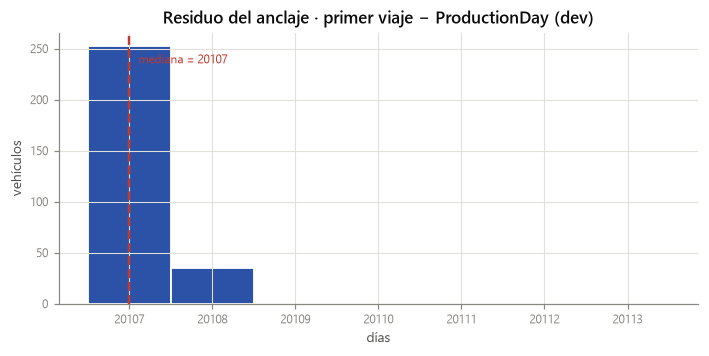

In [13]:
# El anclaje: `primer_viaje - ProductionDay` tiene que ser casi constante entre
# vehículos si `ProductionDay` está en el eje del calendario con origen común.
offset = veh["anchor_offset_days"].dropna()
alternativa = offset - veh.loc[offset.index, "static_daysUntilSale"]
anclaje = pd.DataFrame({
    "primer_viaje − ProductionDay": [offset.std(), offset.quantile(0.75) - offset.quantile(0.25),
                                     offset.max() - offset.min()],
    "… − daysUntilSale": [alternativa.std(), alternativa.quantile(0.75) - alternativa.quantile(0.25),
                          alternativa.max() - alternativa.min()],
}, index=["std [d]", "IQR [d]", "rango [d]"]).round(2)
print(anclaje.to_string())
print(f"\norigen estimado sobre dev: día {META['anchor_origin_day_since_epoch']:.0f} desde epoch "
      f"= {pd.Timestamp('1970-01-01') + pd.Timedelta(days=META['anchor_origin_day_since_epoch']):%Y-%m-%d}")
print("F1 reporta sobre los 1094: std 0,70 · IQR 0,00 · rango 12  ->  el puente se sostiene en dev.")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(offset, bins=np.arange(offset.min() - 0.5, offset.max() + 1.5), color=BLUE,
        edgecolor="white", linewidth=1.2)
ax.axvline(offset.median(), color=ALERT_RED, lw=1.6, ls="--")
ax.annotate(f"mediana = {offset.median():.0f}", xy=(offset.median(), ax.get_ylim()[1] * 0.92),
            xytext=(6, 0), textcoords="offset points", color=ALERT_RED, fontsize=8, va="top")
ax.set_title("Residuo del anclaje · primer viaje − ProductionDay (dev)")
ax.set_xlabel("días")
ax.set_ylabel("vehículos")
plt.show()

**El anclaje se sostiene en dev**: IQR de **0 días** contra un rango de
`ProductionDay` de 337. La traducción del evento al eje de km está técnicamente
disponible. Lo que sigue es qué devuelve al aplicarla.

### 3.2 · La flota pasa sus primeros ~85 días sin moverse

Antes de proyectar el evento sobre el odómetro hace falta saber cómo crece el
odómetro. El perfil por día desde producción lo dice de una: hasta el día ~80 la
mediana de la flota no pasa de 20 km, y a partir de ahí despega. Es el vehículo en
el concesionario —`daysUntilSale` tiene mediana 86 días—.

Esto no es un detalle: significa que **cualquier fecha de evento temprana proyecta
a un odómetro cercano a cero aunque el anclaje sea perfecto.**

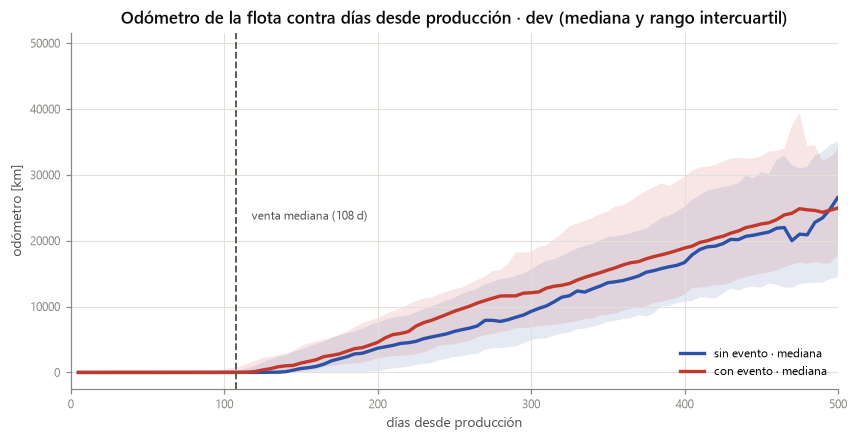

event_observed        sin evento  con evento
day_since_production                        
20                           4.0         4.0
40                           6.0         5.0
60                           7.0         8.0
80                           8.0         9.0
100                         10.0        11.0
120                         13.0       132.0
160                        916.0      1936.0
200                       3681.0      4568.0
300                       9269.0     12108.0


In [14]:
perfil = cache["odo_profile_dev"]
venta_mediana = veh["static_daysUntilSale"].median()

fig, ax = plt.subplots(figsize=(9, 4.2))
for flag in COHORT_ORDER:
    side = perfil[perfil["event_observed"].eq(flag)].sort_values("day_since_production")
    ax.plot(side["day_since_production"], side["median"], color=COHORT_COLORS[flag], lw=2.2,
            label=f"{COHORT_LABELS[flag]} · mediana")
    ax.fill_between(side["day_since_production"], side["p25"], side["p75"],
                    color=COHORT_COLORS[flag], alpha=0.12, lw=0)
ax.axvline(venta_mediana, color=INK["secondary"], lw=1.2, ls="--")
ax.annotate(f"venta mediana ({venta_mediana:.0f} d)", xy=(venta_mediana, ax.get_ylim()[1] * 0.45),
            xytext=(10, 0), textcoords="offset points", fontsize=8, color=INK["secondary"])
ax.set_title("Odómetro de la flota contra días desde producción · dev (mediana y rango intercuartil)")
ax.set_xlabel("días desde producción")
ax.set_ylabel("odómetro [km]")
ax.set_xlim(0, 500)
ax.legend(loc="lower right")
plt.show()

print(perfil[perfil["day_since_production"].isin([20, 40, 60, 80, 100, 120, 160, 200, 300])]
      .pivot(index="day_since_production", columns="event_observed", values="median")
      .rename(columns=COHORT_LABELS).round(0).to_string())

### 3.3 · El universo del estudio: por qué dev son 290 y no 864

Ésta es la sección que cambió de raíz. La versión anterior de este notebook
terminaba acá con un bloqueante; ahora termina con un criterio aplicado.

**El hallazgo, que no cambió:** `IdentificationDate` —la columna que ubica el
evento en el tiempo— viene con dos convenciones de registro mezcladas. En 284 de
los 365 positivos vale **exactamente** lo mismo que `daysUntilSale`, y bajo la
lectura literal del anexo 7.3 eso deja el evento pegado al día de la venta, con el
odómetro en ~13 km y sin historial por delante.

Que sea una convención administrativa y no física lo cierra un conteo que no admite
interpretación: **`IdentificationDate < daysUntilSale` no pasa nunca, 0 de 365**.
Si la fecha marcara el momento real de la falla, alguna caería antes de la venta.

**Lo que sí es nuevo: la convención es del mercado, no del vehículo.** Y eso cambia
qué hay que tirar.

Fecha del evento utilizable, por mercado (los 1081, al congelar el universo):
                        vehículos  sanos  eventos  fecha_real  fecha_por_defecto  frac_usable
static_SalesCountry_cd                                                                       
CNTRY_1                       325    199      126           0                126        0.000
CNTRY_2                       304    199      105           1                104        0.010
CNTRY_3                       146    100       46          19                 27        0.413
CNTRY_4                       257    184       73          61                 12        0.836
CNTRY_5                        49     34       15           0                 15        0.000

Universo del estudio: 1081 -> 364 vehículos · 365 -> 80 eventos
  - 284  positivos sin fecha de evento utilizable
  - 433  vehículos de mercados sin eventos observables  (se conservan ['CNTRY_3', 'CNTRY_4'])


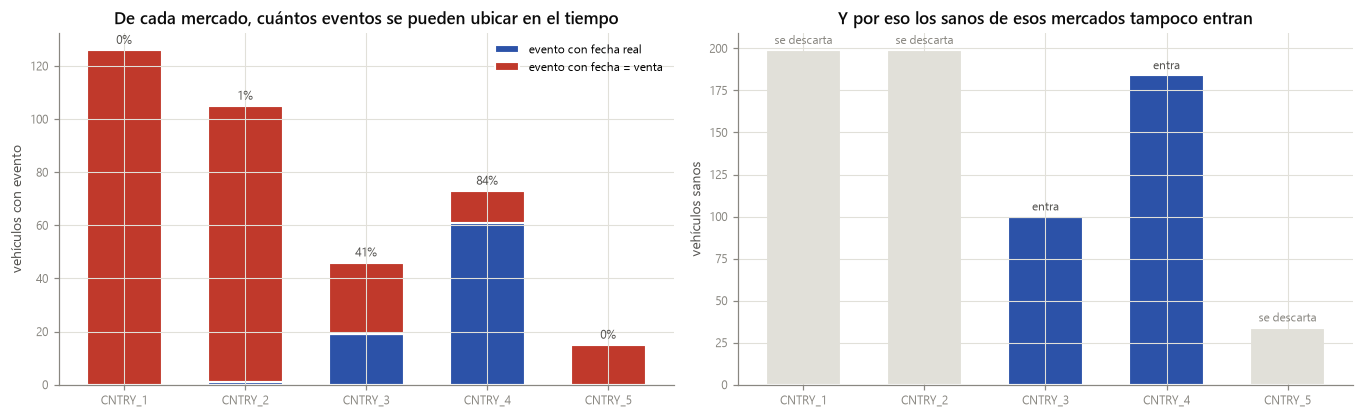

In [15]:
# Este cuadro sale de `test_split.json` (bloque `universe`), que lo dejó congelado
# `scripts/make_test_split.py`. Cubre los 1081 vehículos a propósito: es el REGISTRO
# de una decisión ya tomada sobre la calidad del dato —no una medición que se esté
# haciendo ahora— y define qué mercado entra, no qué modelo gana. La misma lógica
# por la que la auditoría de esquema se hizo sobre el dataset completo.
mercados = pd.DataFrame(META["market_usability"]).set_index("static_SalesCountry_cd")
mercados.columns = ["vehículos", "sanos", "eventos", "fecha_real", "fecha_por_defecto", "frac_usable"]
print("Fecha del evento utilizable, por mercado (los 1081, al congelar el universo):")
print(mercados.to_string(float_format=lambda v: f"{v:.3f}"))

U = META["universe"]
print(f"\nUniverso del estudio: {U['n_input']} -> {U['n_kept']} vehículos"
      f" · {U['events_input']} -> {U['events_kept']} eventos")
print(f"  -{U['n_dropped_no_usable_date']:>4d}  positivos sin fecha de evento utilizable")
print(f"  -{U['n_dropped_market']:>4d}  vehículos de mercados sin eventos observables"
      f"  (se conservan {U['keep_markets']})")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
ax = axes[0]
x = np.arange(len(mercados))
ax.bar(x, mercados["fecha_real"], 0.62, color=BLUE, edgecolor="white", linewidth=1.4,
       label="evento con fecha real")
ax.bar(x, mercados["fecha_por_defecto"], 0.62, bottom=mercados["fecha_real"], color=ALERT_RED,
       edgecolor="white", linewidth=1.4, label="evento con fecha = venta")
for xi, (real, tot) in enumerate(zip(mercados["fecha_real"], mercados["eventos"])):
    ax.annotate(f"{real / tot:.0%}", (xi, tot), textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=8, color=INK["secondary"])
ax.set_xticks(x, mercados.index)
ax.set_ylabel("vehículos con evento")
ax.set_title("De cada mercado, cuántos eventos se pueden ubicar en el tiempo")
ax.legend(loc="upper right")

ax = axes[1]
conserva = mercados.index.isin(U["keep_markets"])
ax.bar(x, mercados["sanos"], 0.62, color=[BLUE if k else INK["grid"] for k in conserva],
       edgecolor="white", linewidth=1.4)
for xi, (s, k) in enumerate(zip(mercados["sanos"], conserva)):
    ax.annotate("entra" if k else "se descarta", (xi, s), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=8,
                color=INK["secondary"] if k else INK["muted"])
ax.set_xticks(x, mercados.index)
ax.set_ylabel("vehículos sanos")
ax.set_title("Y por eso los sanos de esos mercados tampoco entran")
fig.tight_layout()
plt.show()

**Por qué no alcanzaba con filtrar los positivos.** En CNTRY_1 y CNTRY_5 *ningún*
evento tiene fecha utilizable; en CNTRY_2, uno de 105. Si se tiran esos positivos y
se dejan sus vehículos sanos, los tres mercados aportan **432 negativos y 1
positivo**.

Eso no es un desbalance: es **selección sobre el resultado** —se descarta un
vehículo según lo que le pasó— y deja a los negativos viniendo de una población
distinta de la de los positivos. Excluir `SalesCountry_cd` del set de features no lo
arregla, porque el sesgo no está en qué columna ve el modelo sino en quién entró a
la muestra: la tasa base queda inventada y cualquier feature correlacionada con el
mercado hereda el problema.

La salida es simétrica y se puede defender en una frase: **se conservan los
mercados donde el evento se puede observar**. Un vehículo sano de CNTRY_4 es un
negativo legítimo porque, si hubiera fallado, lo habríamos visto. Uno de CNTRY_1
no.

El costo está declarado y es alto: de 365 eventos quedan 80, y el test pasa de 73 a
20. Se acepta porque 73 eventos mal ubicados en el tiempo no permiten medir
anticipación, que es el pedido central del desafío.

> **Lo que el recorte NO arregla:** que los 290 de dev sean dos mercados y no cinco.
> Cualquier conclusión de acá en adelante vale para CNTRY_3 y CNTRY_4; §3.3b mide
> cuánto se parecen entre sí antes de juntarlos en un solo modelo.

### 3.3b · ¿CNTRY_3 y CNTRY_4 se pueden juntar en un solo modelo?

Si los dos mercados que quedan fueran poblaciones distintas, entrenar sobre la
unión sería modelar una mezcla. La pregunta se parte en dos: ¿difieren en **nivel**
(medianas), y ¿difieren en **dirección** (el signo de la correlación con la
etiqueta)?

Nivel: mediana por mercado
static_SalesCountry_cd   CNTRY_3   CNTRY_4  ratio
km_observed             20776.00  15511.00   0.75
n_trips                  1582.00   1496.00   0.95
span_days                 472.19    426.10   0.90
km_per_day                 42.05     34.10   0.81
trip_km_median              2.00      2.00   1.00
short_trip_frac             0.63      0.66   1.04
engine_temp_max_median     90.00     94.00   1.04
below_regime_frac           0.27      0.21   0.77
regen_per_1000km            1.78      2.15   1.21
acumulation_mean           38.40     41.04   1.07
msg_full_per_1000km         2.78     15.11   5.45
air_temp_avg_mean          17.90     26.02   1.45
speed_mean                 31.91     19.38   0.61
urban_trip_frac             0.38      0.51   1.36
static_ProductionDay      122.00    170.00   1.39

Dirección: ρ con `event_observed` dentro de cada mercado
mercado                       CNTRY_3  CNTRY_4  global  mismo signo
variable                                       

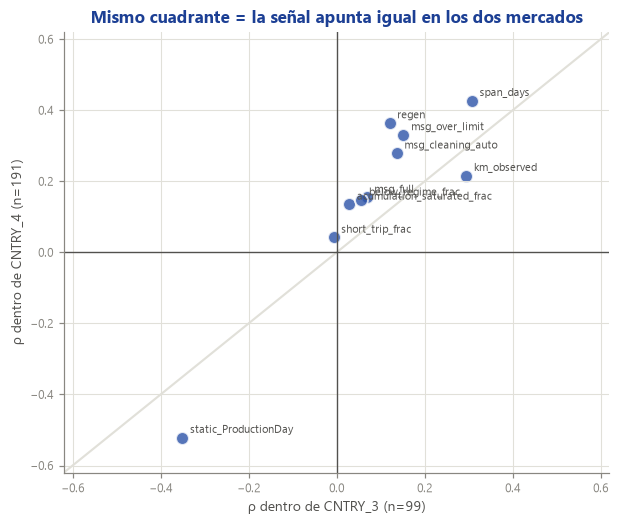

In [16]:
PERFIL = ["km_observed", "n_trips", "span_days", "km_per_day", "trip_km_median",
          "short_trip_frac", "engine_temp_max_median", "below_regime_frac",
          "regen_per_1000km", "acumulation_mean", "msg_full_per_1000km",
          "air_temp_avg_mean", "speed_mean", "urban_trip_frac", "static_ProductionDay"]
perfil = veh.groupby("static_SalesCountry_cd", observed=True)[PERFIL].median().T
perfil["ratio"] = (perfil["CNTRY_4"] / perfil["CNTRY_3"]).round(2)
print("Nivel: mediana por mercado")
print(perfil.round(2).to_string())

TOP = ["regen_per_1000km", "msg_over_limit_per_1000km", "msg_cleaning_auto_per_1000km",
       "msg_full_per_1000km", "acumulation_saturated_frac", "below_regime_frac",
       "short_trip_frac", "km_observed", "span_days", "static_ProductionDay"]
filas = []
for cty, grupo in veh.groupby("static_SalesCountry_cd", observed=True):
    for columna in TOP:
        filas.append({"variable": columna, "mercado": cty,
                      "rho": spearmanr(grupo[columna], grupo["event_observed"],
                                       nan_policy="omit").statistic})
direccion = pd.DataFrame(filas).pivot(index="variable", columns="mercado", values="rho")
direccion["global"] = [spearmanr(veh[v], veh["event_observed"], nan_policy="omit").statistic
                       for v in direccion.index]
direccion["mismo signo"] = np.sign(direccion["CNTRY_3"]) == np.sign(direccion["CNTRY_4"])
direccion = direccion.reindex(direccion["global"].abs().sort_values(ascending=False).index)
print("\nDirección: ρ con `event_observed` dentro de cada mercado")
print(direccion.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(direccion["CNTRY_3"], direccion["CNTRY_4"], s=70, color=BLUE, alpha=0.8,
           edgecolor="white", linewidth=1.2)
for nombre, fila in direccion.iterrows():
    ax.annotate(nombre.replace("_per_1000km", ""), (fila["CNTRY_3"], fila["CNTRY_4"]),
                textcoords="offset points", xytext=(5, 3), fontsize=7, color=INK["secondary"])
lim = 0.62
ax.plot([-lim, lim], [-lim, lim], color=INK["grid"], lw=1.4, zorder=0)
ax.axhline(0, color=INK["secondary"], lw=0.9)
ax.axvline(0, color=INK["secondary"], lw=0.9)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("ρ dentro de CNTRY_3 (n=99)")
ax.set_ylabel("ρ dentro de CNTRY_4 (n=191)")
ax.set_title("Mismo cuadrante = la señal apunta igual en los dos mercados", color=FORD_BLUE,
             fontweight="bold")
plt.show()

**Se pueden juntar, con una advertencia.**

En **dirección** coinciden: 9 de las 10 variables del ranking caen en el mismo
cuadrante, y la décima (`short_trip_frac`) es ρ ≈ 0 en los dos, o sea que no
discrepan, simplemente no dicen nada. No hay ninguna variable que prediga evento en
un mercado y salud en el otro, que es el escenario que obligaría a modelar por
separado.

En **nivel** difieren, y bastante: CNTRY_4 es 8 °C más cálido de media
(26,0 vs 17,9 °C), circula a la mitad de velocidad (19,4 vs 31,9 km/h) y es más
urbano (0,51 vs 0,38). El que se lleva el premio es `msg_full_per_1000km`: **5,45x**
más alto en CNTRY_4. Eso es un desplazamiento de escala por mercado, no una
inversión de la relación.

**Consecuencia práctica para F2:** las features de tasa absoluta —`msg_*_per_1000km`
sobre todo— arrastran el nivel del mercado. Con 191 vehículos de CNTRY_4 y 99 de
CNTRY_3 el modelo puede aprender el mercado en vez del síntoma. Vale la pena medir
una variante con esas tasas normalizadas dentro del mercado (el ranking o el
z-score por país), **calculada dentro del train de cada fold** como manda la regla
3. No se hace acá: es feature engineering y esto es un EDA.

### 3.4 · El evento sobre el eje de km, ahora sí

Con el universo recortado, los 60 eventos de dev tienen fecha discriminante por
construcción. La pregunta ya no es si se pueden ubicar, sino **cuánto historial
dejan por delante** —que es lo que decide si hay ventana W que agregar y gap G que
blanquear—.

vehículos con evento en dev                     : 60
  con IdentificationDate == daysUntilSale       : 0  (los saca el universo)
  delta Ident - venta: mediana 163 d · rango 1-268 d

odómetro del evento · mediana [km]             7987.3
odómetro del evento · p25 [km]                 3036.5
odómetro del evento · p75 [km]                12813.5
% de viajes ANTES del evento (mediana)           39.1
viajes antes del evento (mediana)               733.5
km recorridos DESPUÉS del evento (mediana)    15635.9
eventos con <5% del historial por delante         3.0
eventos con <2.000 km de odómetro                10.0

Dónde cae el evento respecto de la ventana de viajes observada:
event_source
interpolado                  58
posterior_al_ultimo_viaje     2


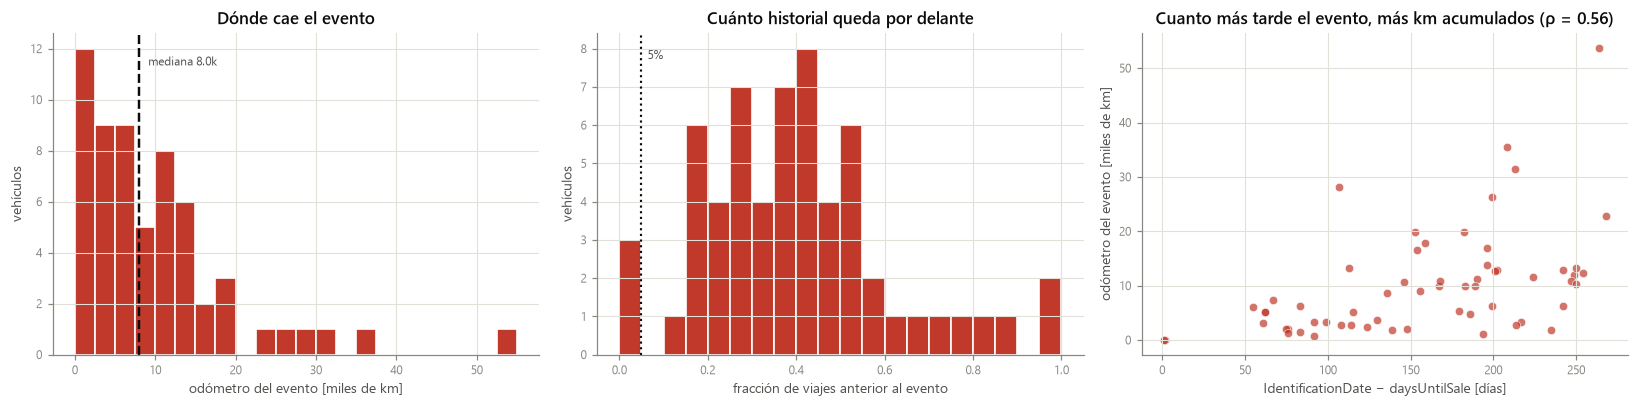


Los que el criterio deja pasar pero siguen sin historial útil:
vehicle_id  delta_ident_venta  event_odo_km  event_frac_trips_before  n_trips  km_observed
  VEH_0056                  2             5                  0.02268      972    1.189e+04
  VEH_0499                  1             8                  0.02754     1387    2.328e+04
  VEH_0537                 92           803                   0.1648     1779    1.166e+04
  VEH_0587                194          1048                   0.3372     1635         7460


In [17]:
eventos = veh[veh["event_observed"].eq(1)].copy()
eventos["delta_ident_venta"] = eventos["event_day_since_production"] - eventos["static_daysUntilSale"]
eventos["km_post_evento"] = eventos["km_observed"] - eventos["event_odo_km"]

assert int(eventos["ident_equals_sale"].sum()) == 0, \
    "quedó un evento con fecha = venta: el filtro del universo no se aplicó"
print(f"vehículos con evento en dev                     : {len(eventos)}")
print(f"  con IdentificationDate == daysUntilSale       : 0  (los saca el universo)")
print(f"  delta Ident - venta: mediana {eventos['delta_ident_venta'].median():.0f} d"
      f" · rango {eventos['delta_ident_venta'].min():.0f}-{eventos['delta_ident_venta'].max():.0f} d")

resumen = pd.Series({
    "odómetro del evento · mediana [km]": eventos["event_odo_km"].median(),
    "odómetro del evento · p25 [km]": eventos["event_odo_km"].quantile(0.25),
    "odómetro del evento · p75 [km]": eventos["event_odo_km"].quantile(0.75),
    "% de viajes ANTES del evento (mediana)": 100 * eventos["event_frac_trips_before"].median(),
    "viajes antes del evento (mediana)": eventos["event_trips_before"].median(),
    "km recorridos DESPUÉS del evento (mediana)": eventos["km_post_evento"].median(),
    "eventos con <5% del historial por delante": int((eventos["event_frac_trips_before"] < 0.05).sum()),
    "eventos con <2.000 km de odómetro": int((eventos["event_odo_km"] < 2000).sum()),
}, name="dev · 60 eventos")
print("\n" + resumen.round(1).to_string())
print("\nDónde cae el evento respecto de la ventana de viajes observada:")
print(eventos["event_source"].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
ax = axes[0]
ax.hist(eventos["event_odo_km"] / 1000, bins=np.arange(0, 56, 2.5), color=ALERT_RED,
        edgecolor="white", linewidth=1.1)
ax.axvline(eventos["event_odo_km"].median() / 1000, color=INK["primary"], lw=1.6, ls="--")
ax.annotate(f"mediana {eventos['event_odo_km'].median() / 1000:.1f}k",
            (eventos["event_odo_km"].median() / 1000, ax.get_ylim()[1] * 0.9),
            textcoords="offset points", xytext=(6, 0), fontsize=8, color=INK["secondary"])
ax.set_xlabel("odómetro del evento [miles de km]")
ax.set_ylabel("vehículos")
ax.set_title("Dónde cae el evento")

ax = axes[1]
ax.hist(eventos["event_frac_trips_before"], bins=np.arange(0, 1.05, 0.05), color=ALERT_RED,
        edgecolor="white", linewidth=1.1)
ax.axvline(0.05, color=INK["primary"], lw=1.4, ls=":")
ax.annotate("5%", (0.05, ax.get_ylim()[1] * 0.92), textcoords="offset points", xytext=(4, 0),
            fontsize=8, color=INK["secondary"])
ax.set_xlabel("fracción de viajes anterior al evento")
ax.set_ylabel("vehículos")
ax.set_title("Cuánto historial queda por delante")

ax = axes[2]
ax.scatter(eventos["delta_ident_venta"], eventos["event_odo_km"] / 1000, s=30, color=ALERT_RED,
           alpha=0.7, edgecolor="white", linewidth=0.5)
ax.set_xlabel("IdentificationDate − daysUntilSale [días]")
ax.set_ylabel("odómetro del evento [miles de km]")
ax.set_title("Cuanto más tarde el evento, más km acumulados (ρ = %.2f)" %
             spearmanr(eventos["delta_ident_venta"], eventos["event_odo_km"]).statistic)
fig.tight_layout()
plt.show()

print("\nLos que el criterio deja pasar pero siguen sin historial útil:")
print(eventos.nsmallest(4, "event_odo_km")[
    ["vehicle_id", "delta_ident_venta", "event_odo_km", "event_frac_trips_before",
     "n_trips", "km_observed"]].to_string(index=False, float_format=lambda v: f"{v:.4g}"))

**El evento ahora es utilizable, y por un margen cómodo.** Mediana de **7.987 km**
de odómetro y **39%** del historial de viajes por delante (733 viajes), contra los
13 km y 2,3% del grupo que se descartó. 58 de los 60 eventos caen **interpolados**
entre dos viajes reales; los otros 2 quedan después del último viaje registrado.

Tres cosas que salen de acá y que F2 tiene que usar:

1. **El criterio es necesario pero no suficiente.** Dos vehículos pasan el filtro
   con delta de 1 y 2 días (`VEH_0499`, `VEH_0056`) y caen igual en 8 y 5 km de
   odómetro: son el mismo caso "fecha = venta" con un día de corrimiento. Son 2 de
   60 y el panel los va a descartar solo, porque no van a tener viajes suficientes
   en ninguna ventana (`sampling.min_trips_in_window` en `panel_v1.yaml`). Conviene
   que sea explícito y no un efecto lateral.
2. **El evento no es el fin de la vida del vehículo.** Después del evento siguen
   registrándose **15.636 km** de mediana. Eso confirma que `IdentificationDate`
   marca una identificación —un diagnóstico, una entrada a taller— y no una baja.
   Para el panel significa que hay historial post-evento que **no** puede entrar en
   ninguna ventana: los cortes se generan sobre el tramo previo, y el resto se tira.
3. **El delta correlaciona con el odómetro del evento a ρ = 0,56.** La traducción
   de días a km es coherente: eventos más tardíos caen en odómetros más altos. Es
   una verificación barata de que el anclaje de §3.1 no está inventando posiciones.

### 3.5 · Supervivencia sobre el eje de odómetro (Kaplan-Meier)

Duración = odómetro del evento si el vehículo tiene evento, último odómetro
observado (`trip_odo_max`) si está censurado. **El lado censurado no depende del
anclaje**: `trip_odo_max` es dato directo. El lado de los eventos sí, así que la
curva se muestra con las dos hipótesis y con el caveat puesto.

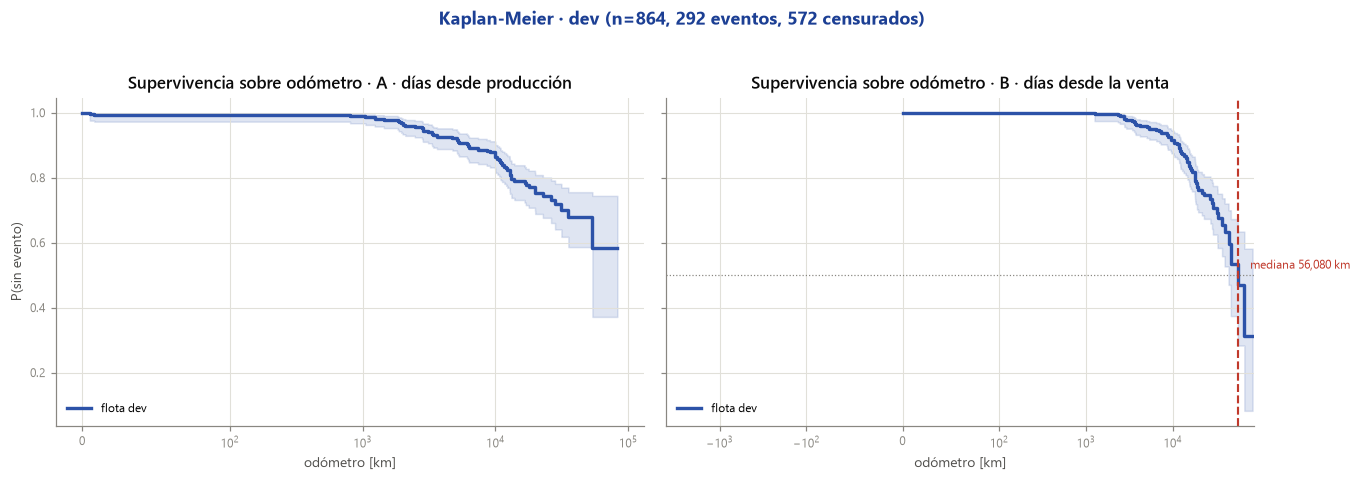

In [18]:
def km_fit(frame, duracion, evento, etiqueta):
    kmf = KaplanMeierFitter(label=etiqueta)
    kmf.fit(frame[duracion].clip(lower=1), frame[evento])
    return kmf


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, (columna, titulo) in zip(axes, [("duration_km", "A · días desde producción"),
                                        ("duration_km_alt", "B · días desde la venta")]):
    kmf = km_fit(veh, columna, "event_observed", "flota dev")
    kmf.plot_survival_function(ax=ax, color=BLUE, lw=2.2, ci_alpha=0.15)
    mediana = kmf.median_survival_time_
    if np.isfinite(mediana):
        ax.axhline(0.5, color=INK["muted"], lw=0.8, ls=":")
        ax.axvline(mediana, color=ALERT_RED, lw=1.4, ls="--")
        ax.annotate(f"mediana {mediana:,.0f} km", xy=(mediana, 0.52), xytext=(8, 0),
                    textcoords="offset points", fontsize=8, color=ALERT_RED)
    ax.set_title(f"Supervivencia sobre odómetro · {titulo}")
    ax.set_xlabel("odómetro [km]")
    ax.set_ylabel("P(sin evento)")
    ax.set_xscale("symlog", linthresh=100)
    ax.legend(loc="lower left")
fig.suptitle("Kaplan-Meier · dev (n=864, 292 eventos, 572 censurados)", y=1.03,
             color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

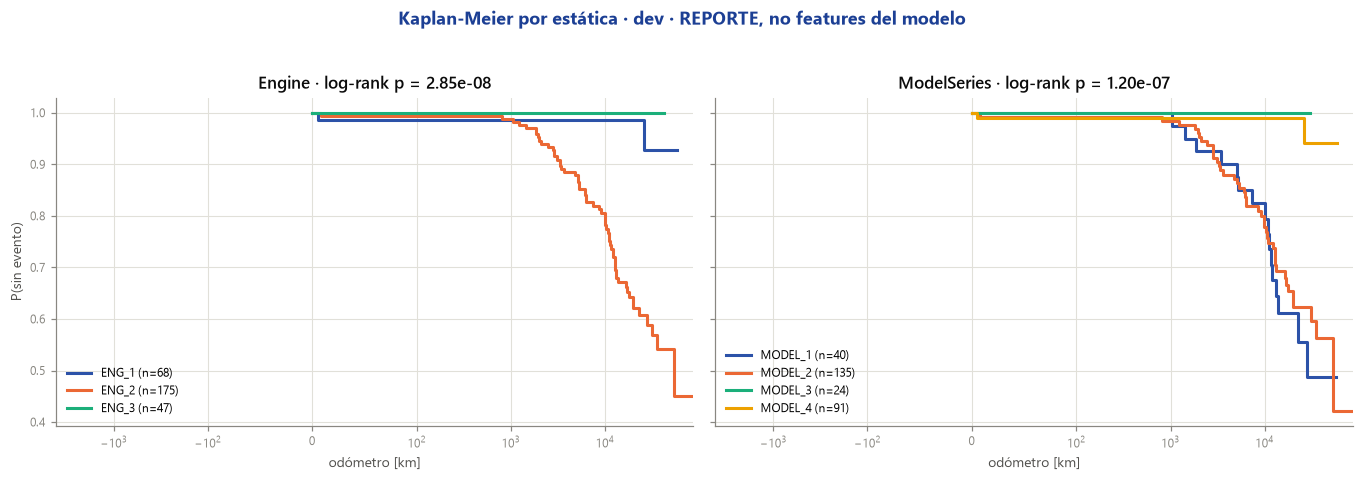

La curva plana de ENG_3 es el sesgo de muestreo de §2, no un motor mejor:
con 0 eventos en 212 vehículos, la curva no puede bajar. Por eso `Engine` no entra al modelo.


In [19]:
# Por motor y por modelo. REPORTE, no modelado: `Engine` está excluido del set base.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, columna in zip(axes, ["static_Engine", "static_ModelSeries"]):
    for i, (nivel, grupo) in enumerate(veh.groupby(columna, observed=True)):
        if len(grupo) < 20:
            continue
        kmf = km_fit(grupo, "duration_km", "event_observed", f"{nivel} (n={len(grupo)})")
        kmf.plot_survival_function(ax=ax, color=CATEGORICAL[i % len(CATEGORICAL)], lw=2, ci_show=False)
    prueba = multivariate_logrank_test(veh["duration_km"].clip(lower=1), veh[columna],
                                       veh["event_observed"])
    ax.set_title(f"{columna.replace('static_', '')} · log-rank p = {prueba.p_value:.2e}")
    ax.set_xlabel("odómetro [km]")
    ax.set_ylabel("P(sin evento)")
    ax.set_xscale("symlog", linthresh=100)
    ax.legend(loc="lower left", ncol=1)
fig.suptitle("Kaplan-Meier por estática · dev · REPORTE, no features del modelo", y=1.03,
             color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

print("La curva plana de ENG_3 es el sesgo de muestreo de §2, no un motor mejor:")
print("con 0 eventos en 212 vehículos, la curva no puede bajar. Por eso `Engine` no entra al modelo.")

## 4 · Calidad del eje de odómetro

El odómetro es el eje por defecto del contrato (regla 4), así que sus defectos son
los defectos del panel. `docs/memoria/f1-calidad-odometro.md` los midió sobre el
universo completo; acá se recuentan sobre dev y se compara.

In [20]:
nulos_odo = veh["signal_odo_null"] / veh["n_signals"]
calidad = pd.DataFrame([
    {"problema": "`OdometerValue` nulo en `signals` (global)",
     "dev": veh["signal_odo_null"].sum() / veh["n_signals"].sum(),
     "documentado (1081)": 0.1115, "unidad": "fracción de filas"},
    {"problema": "`OdometerValue` nulo · mediana POR VEHÍCULO",
     "dev": nulos_odo.median(), "documentado (1081)": np.nan, "unidad": "fracción de filas"},
    {"problema": "`KilometerPerHour` nulo en `trips`",
     "dev": (veh["speed_null_frac"] * veh["n_trips"]).sum() / veh["n_trips"].sum(),
     "documentado (1081)": 0.3247, "unidad": "fracción de filas"},
    {"problema": "vehículos con algún viaje de km negativo",
     "dev": int((veh["n_km_negative"] > 0).sum()), "documentado (1081)": 24, "unidad": "vehículos"},
    {"problema": "viajes con km negativo",
     "dev": int(veh["n_km_negative"].sum()), "documentado (1081)": 165, "unidad": "viajes"},
])
print(calidad.to_string(index=False))

                                   problema        dev  documentado (1081)            unidad
 `OdometerValue` nulo en `signals` (global)   0.000089              0.1115 fracción de filas
`OdometerValue` nulo · mediana POR VEHÍCULO   0.000000                 NaN fracción de filas
         `KilometerPerHour` nulo en `trips`   0.353810              0.3247 fracción de filas
   vehículos con algún viaje de km negativo   8.000000             24.0000         vehículos
                     viajes con km negativo 137.000000            165.0000            viajes


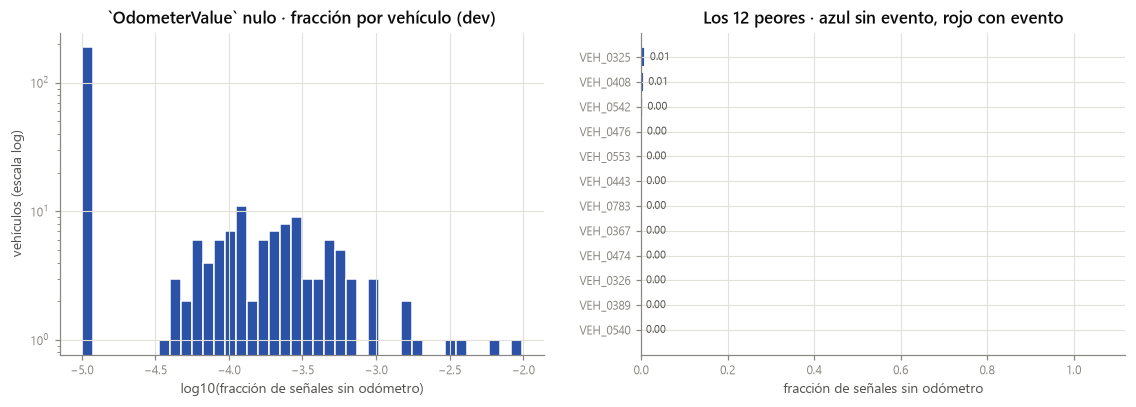

vehículos con >50% de sus señales sin odómetro : 0
vehículos con  <1% de sus señales sin odómetro : 290 de 290
mediana por vehículo                           : 0.00000


In [21]:
# El hallazgo: el 11% de nulos no está repartido, está concentrado en un puñado de vehículos.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax = axes[0]
ax.hist(np.log10(nulos_odo.clip(lower=1e-5)), bins=40, color=BLUE, edgecolor="white", linewidth=1.0)
ax.set_yscale("log")
ax.set_title("`OdometerValue` nulo · fracción por vehículo (dev)")
ax.set_xlabel("log10(fracción de señales sin odómetro)")
ax.set_ylabel("vehículos (escala log)")

ax = axes[1]
peores = veh.assign(frac_nulo=nulos_odo).nlargest(12, "frac_nulo")
colores = [COHORT_COLORS[int(f)] for f in peores["event_observed"]]
barras = ax.barh(peores["vehicle_id"], peores["frac_nulo"], color=colores, edgecolor="white", linewidth=1.2)
ax.bar_label(barras, fmt="%.2f", fontsize=7, color=INK["secondary"], padding=3)
ax.invert_yaxis()
ax.set_xlim(0, 1.12)
ax.set_title("Los 12 peores · azul sin evento, rojo con evento")
ax.set_xlabel("fracción de señales sin odómetro")
plt.show()

print(f"vehículos con >50% de sus señales sin odómetro : {int((nulos_odo > 0.5).sum())}")
print(f"vehículos con  <1% de sus señales sin odómetro : {int((nulos_odo < 0.01).sum())} de {len(veh)}")
print(f"mediana por vehículo                           : {nulos_odo.median():.5f}")

**El problema del odómetro nulo se fue con el recorte del universo, y vale la pena
entender por qué.** `f1-calidad-odometro.md` midió sobre los 1081 un 11,15% de
`OdometerValue` nulo en `signals`, y la versión anterior de este EDA agregó que ese
11% no estaba repartido sino **concentrado en cuatro vehículos** con entre el 66% y
el 97% de sus señales sin odómetro.

Sobre los 290 de dev del universo recortado el nulo global es **0,009%**, la mediana
por vehículo es 0,00% y **los 290 están por debajo del 1%**: ni un solo vehículo con
más de la mitad de sus señales sin odómetro.

Los cuatro vehículos problemáticos **estaban en los mercados descartados**. Eso no
es casualidad ni suerte: refuerza la lectura de §3.3 de que la calidad del registro
es una propiedad del mercado, y no solo para `IdentificationDate`.

Consecuencia práctica para F2: **descartar las filas de `signals` sin odómetro ya no
tiene costo.** La imputación por el viaje que contiene al `eventTimestamp`, que la
versión anterior marcaba como necesaria para cuatro vehículos, deja de hacer falta.
El que sí empeoró es `KilometerPerHour`: 35,4% de nulos contra el 32,5% de los
1081.

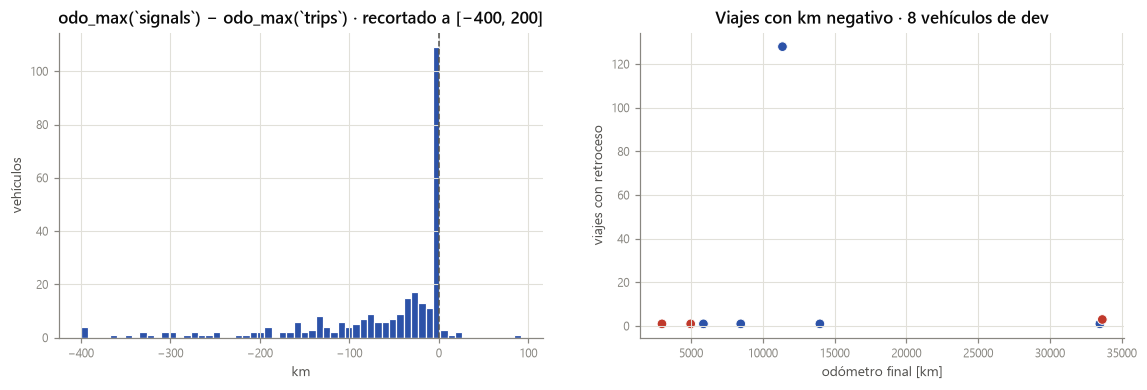

count    290.0
mean     -64.9
std      104.2
min     -900.0
5%      -272.8
25%      -89.8
50%      -25.0
75%        0.0
95%        0.0
max       92.0

Documentado sobre los 1081: mediana −18 km, p25 −77 km, mínimo −7821 km.
`trips` manda como eje y `signals` se alinea contra él (f1-calidad-odometro.md).


In [22]:
# Desfase entre los dos odómetros y retrocesos.
desfase = (veh["signal_odo_max"] - veh["trip_odo_max"]).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
ax = axes[0]
ax.hist(desfase.clip(-400, 200), bins=60, color=BLUE, edgecolor="white", linewidth=0.8)
ax.axvline(0, color=INK["secondary"], lw=1.0, ls="--")
ax.set_title("odo_max(`signals`) − odo_max(`trips`) · recortado a [−400, 200]")
ax.set_xlabel("km")
ax.set_ylabel("vehículos")

ax = axes[1]
retroceso = veh[veh["n_km_negative"] > 0]
ax.scatter(retroceso["trip_odo_max"], retroceso["n_km_negative"],
           c=[COHORT_COLORS[int(f)] for f in retroceso["event_observed"]], s=40,
           edgecolor="white", linewidth=0.6)
ax.set_title(f"Viajes con km negativo · {len(retroceso)} vehículos de dev")
ax.set_xlabel("odómetro final [km]")
ax.set_ylabel("viajes con retroceso")
plt.show()

print(desfase.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1).to_string())
print("\nDocumentado sobre los 1081: mediana −18 km, p25 −77 km, mínimo −7821 km.")
print("`trips` manda como eje y `signals` se alinea contra él (f1-calidad-odometro.md).")

## 5 · Uso y contexto (`trips`)

1.947.866 viajes de dev, ya deduplicados. Dos grabados distintos:

- **distribuciones a nivel viaje** (histogramas y cuantiles **exactos** sobre los
  1,9M, no una muestra);
- **boxplots a nivel vehículo**, donde cada punto es un vehículo. Son los que
  importan para F2: las features del panel van a ser agregados por vehículo y
  ventana, así que la pregunta es cuánto se separan los **vehículos**, no los
  viajes.

### 5.1 · Distribuciones a nivel viaje

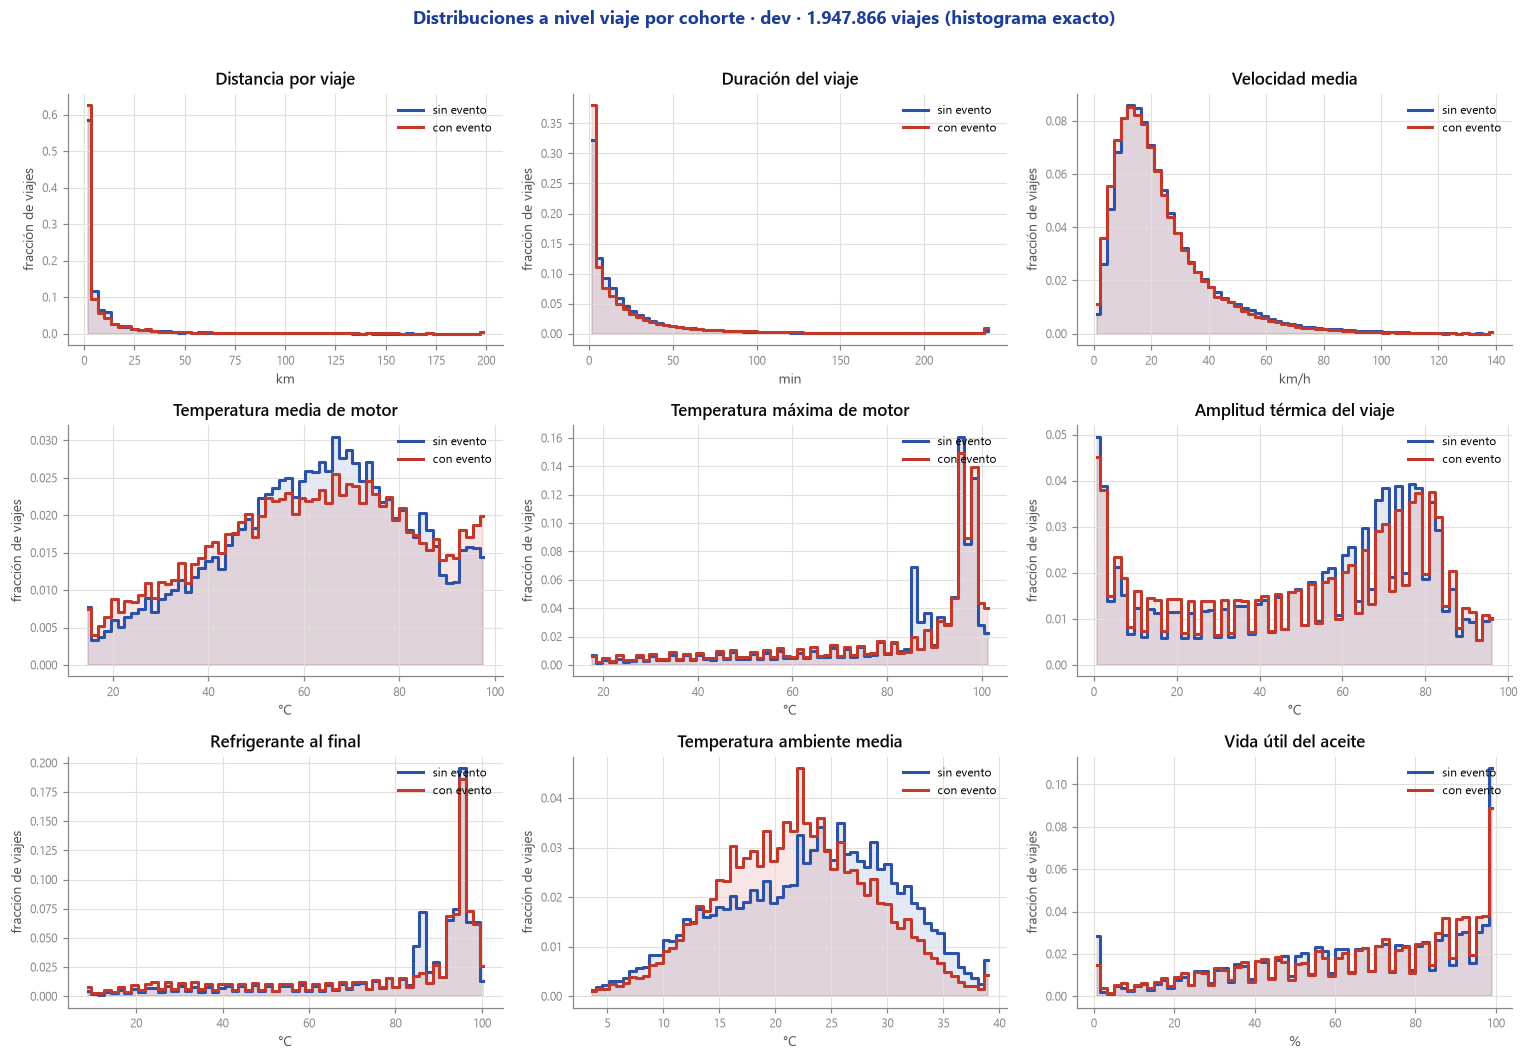

In [23]:
hist = cache["trip_hist_dev"]
PANEL_VIAJE = [
    ("trip_km", "Distancia por viaje", "km"),
    ("trip_duration_min", "Duración del viaje", "min"),
    ("KilometerPerHour", "Velocidad media", "km/h"),
    ("EngineTemperatureAvg", "Temperatura media de motor", "°C"),
    ("EngineTemperatureMax", "Temperatura máxima de motor", "°C"),
    ("engine_temp_amplitude", "Amplitud térmica del viaje", "°C"),
    ("CoolantTemperatureEnd", "Refrigerante al final", "°C"),
    ("AirTemperatureAvg", "Temperatura ambiente media", "°C"),
    ("EngineOilLifePCStart", "Vida útil del aceite", "%"),
]
fig, axes = plt.subplots(3, 3, figsize=(14, 9.5))
for ax, (metrica, titulo, unidad) in zip(axes.ravel(), PANEL_VIAJE):
    cohort_hist(ax, hist, metrica, titulo=titulo, xlabel=unidad)
fig.suptitle("Distribuciones a nivel viaje por cohorte · dev · 1.947.866 viajes (histograma exacto)",
             y=1.01, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [24]:
# Cuantiles exactos, que es lo que un histograma no deja leer con precisión.
cuant = cache["trip_quantiles_dev"]
tabla = cuant[cuant["q"].isin([0.05, 0.25, 0.5, 0.75, 0.95])].pivot_table(
    index="metric", columns=["event_observed", "q"], values="value")
tabla.columns = [f"{COHORT_LABELS[a]} · p{int(b * 100)}" for a, b in tabla.columns]
tabla.loc[[m for m, _, _ in PANEL_VIAJE]].round(2)

,sin evento · p5,sin evento · p25,sin evento · p50,sin evento · p75,sin evento · p95,con evento · p5,con evento · p25,con evento · p50,con evento · p75,con evento · p95
metric,,,,,,,,,,
trip_km,0.00,0.00,2.00,9.00,47.00,0.00,0.00,1.00,8.00,52.00
trip_duration_min,0.00,2.18,10.07,26.82,88.18,0.00,1.18,8.42,27.25,105.38
KilometerPerHour,5.63,12.22,19.30,30.38,58.99,4.82,11.48,18.59,29.17,55.38
EngineTemperatureAvg,26.50,49.00,63.67,77.00,93.77,24.25,46.00,62.75,78.00,94.57
EngineTemperatureMax,35.00,78.00,93.00,97.00,100.00,32.00,70.00,94.00,97.00,100.00
engine_temp_amplitude,2.00,27.00,60.00,75.00,88.00,2.00,23.00,57.00,76.00,89.00
CoolantTemperatureEnd,27.00,71.00,90.00,95.00,98.00,22.00,57.00,91.00,96.00,98.00
AirTemperatureAvg,9.75,17.38,23.75,28.80,34.62,10.56,17.00,21.93,26.50,33.00
EngineOilLifePCStart,12.00,46.00,69.00,89.00,100.00,14.00,46.00,72.00,90.00,100.00


### 5.2 · Agregados por vehículo: dónde se separan las cohortes

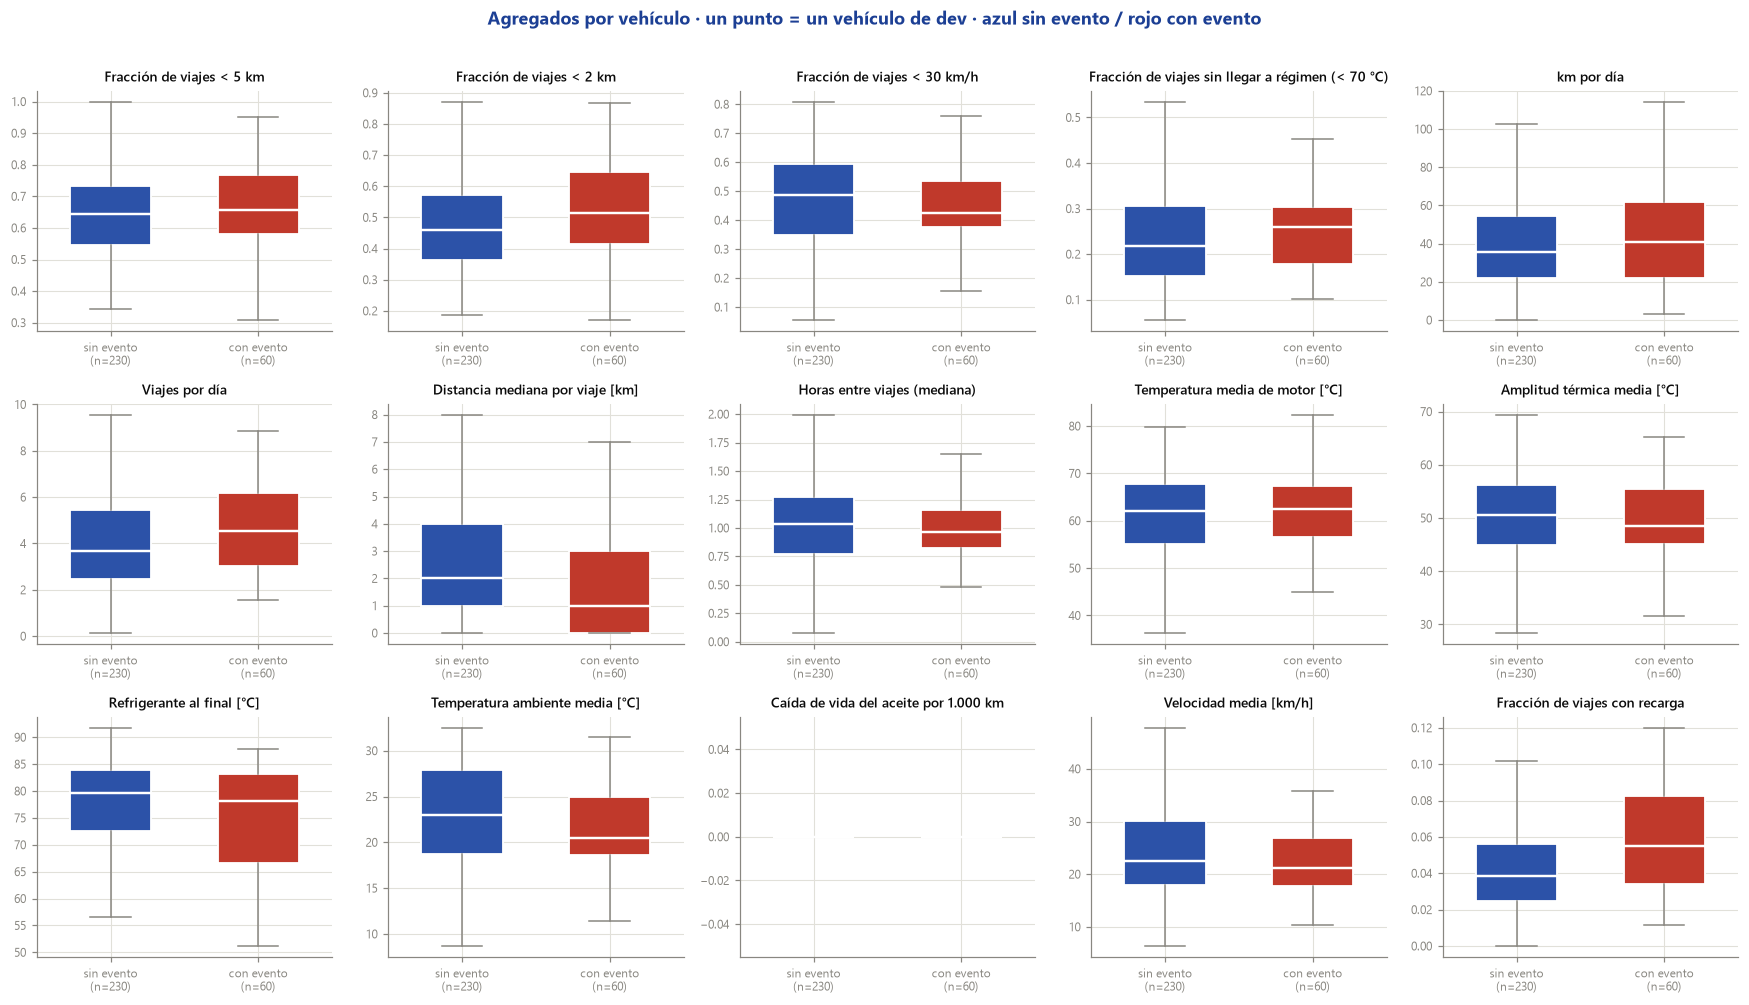

In [25]:
USO_POR_VEHICULO = [
    ("short_trip_frac", "Fracción de viajes < 5 km"),
    ("very_short_trip_frac", "Fracción de viajes < 2 km"),
    ("urban_trip_frac", "Fracción de viajes < 30 km/h"),
    ("below_regime_frac", "Fracción de viajes sin llegar a régimen (< 70 °C)"),
    ("km_per_day", "km por día"),
    ("trips_per_day", "Viajes por día"),
    ("trip_km_median", "Distancia mediana por viaje [km]"),
    ("hours_between_trips_median", "Horas entre viajes (mediana)"),
    ("engine_temp_avg_median", "Temperatura media de motor [°C]"),
    ("engine_temp_amplitude_mean", "Amplitud térmica media [°C]"),
    ("coolant_end_mean", "Refrigerante al final [°C]"),
    ("air_temp_avg_mean", "Temperatura ambiente media [°C]"),
    ("oil_life_drop_per_1000km", "Caída de vida del aceite por 1.000 km"),
    ("speed_mean", "Velocidad media [km/h]"),
    ("refuel_frac", "Fracción de viajes con recarga"),
]
fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for ax, (columna, titulo) in zip(axes.ravel(), USO_POR_VEHICULO):
    cohort_box(ax, veh, columna, titulo=titulo)
    ax.set_title(titulo, fontsize=9)
fig.suptitle("Agregados por vehículo · un punto = un vehículo de dev · azul sin evento / rojo con evento",
             y=1.01, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [26]:
comparacion_uso = compara_cohortes(veh, [c for c, _ in USO_POR_VEHICULO])
print("`prob_supera` = P(un vehículo con evento > uno sano). 0,5 = sin diferencia.")
comparacion_uso.round(4)

`prob_supera` = P(un vehículo con evento > uno sano). 0,5 = sin diferencia.


,variable,mediana_sanos,mediana_evento,ratio,prob_supera,p_mannwhitney
14,refuel_frac,0.0384,0.0553,1.4403,0.6279,0.0023
5,trips_per_day,3.6673,4.5189,1.2322,0.6120,0.0076
6,trip_km_median,2.0000,1.0000,0.5000,0.4182,0.0475
1,very_short_trip_frac,0.4593,0.5129,1.1166,0.5813,0.0525
11,air_temp_avg_mean,22.9659,20.4309,0.8896,0.4201,0.0569
3,below_regime_frac,0.2189,0.2606,1.1907,0.5717,0.0872
10,coolant_end_mean,79.7053,78.1248,0.9802,0.4370,0.1328
4,km_per_day,35.8124,40.9128,1.1424,0.5578,0.1680
2,urban_trip_frac,0.4868,0.4265,0.8762,0.4587,0.3249
7,hours_between_trips_median,1.0378,0.9676,0.9324,0.4593,0.3322


**Lectura.** Las familias A (térmica / trayectos cortos) y C (uso) separan poco: la
probabilidad de superación se queda entre 0,45 y 0,56 en todas. El
`below_regime_frac` —la traducción más directa de la hipótesis causal del
enunciado— apenas se mueve.

Eso no las descarta: acá se está comparando el **historial completo** de cada
vehículo, que no es lo que va a ver el modelo. F2 las mide sobre una ventana W
móvil, donde un vehículo puede tener meses de uso urbano intenso y después
normalizar. Lo que esta tabla sí dice es que **no hay que esperar que el uso
resuelva el problema por sí solo**: la señal fuerte está en §6.

### 5.3 · Rangos imposibles y la trampa de `EngineOilLifePC`

Antes de convertir nada en feature conviene mirar los extremos. Hay dos cosas
distintas acá: valores fuera de rango físico (que se recortan) y una columna que
está completa, varía, y aun así no sirve para la feature que el plan §4 le asignó.

In [27]:
muestra_viajes = check_dev_only(cache["trips_sample_dev"], "trips_sample_dev")

RANGOS_ESPERADOS = {
    "KilometerPerHour": (0, 200, "km/h"),
    "FuelLvlStartPc": (0, 100, "%"),
    "FuelLvlEndPc": (0, 100, "%"),
    "AirTemperatureAvg": (-30, 55, "°C"),
    "CoolantTemperatureStart": (-40, 130, "°C"),
    "EngineTemperatureMax": (-40, 130, "°C"),
    "trip_km": (0, 2000, "km"),
    "trip_duration_min": (0, 1440, "min"),
}
filas = []
for columna, (bajo, alto, unidad) in RANGOS_ESPERADOS.items():
    serie = muestra_viajes[columna].dropna()
    filas.append({
        "columna": columna, "unidad": unidad,
        "min": serie.min(), "p01": serie.quantile(0.01), "p99": serie.quantile(0.99),
        "max": serie.max(),
        "rango esperado": f"[{bajo}, {alto}]",
        "frac fuera de rango": float(((serie < bajo) | (serie > alto)).mean()),
    })
rangos = pd.DataFrame(filas)
print("Sobre la muestra de 250.000 viajes de dev (los cuantiles del cache son exactos;")
print("esta tabla mira colas, que es donde la muestra alcanza):")
rangos.round(4)

  [ok] trips_sample_dev           250000 filas ·  290 vehículos · 0 de test
Sobre la muestra de 250.000 viajes de dev (los cuantiles del cache son exactos;
esta tabla mira colas, que es donde la muestra alcanza):


,columna,unidad,min,p01,p99,max,rango esperado,frac fuera de rango
0,KilometerPerHour,km/h,0.0021,2.5370,86.9547,203400.0000,"[0, 200]",0.0004
1,FuelLvlStartPc,%,-5.2174,1.0870,102.8264,103.6960,"[0, 100]",0.1167
2,FuelLvlEndPc,%,-5.2174,0.9783,102.7177,103.4786,"[0, 100]",0.1107
3,AirTemperatureAvg,°C,-52.6000,5.1250,37.7500,79.1250,"[-30, 55]",0.0001
4,CoolantTemperatureStart,°C,-6.0000,2.0000,98.0000,112.0000,"[-40, 130]",0.0000
5,EngineTemperatureMax,°C,1.0000,21.0000,101.0000,115.0000,"[-40, 130]",0.0000
6,trip_km,km,-231.0000,0.0000,130.0000,893.0000,"[0, 2000]",0.0002
7,trip_duration_min,min,0.0000,0.0000,195.2500,41763.7833,"[0, 1440]",0.0001


viajes de la muestra con el dato               : 250,000 de 250,000
`EngineOilLifePCStart` == `EngineOilLifePCEnd` : 1.0000
delta intra-viaje distinto de cero             : 0 viajes

El NIVEL sí varía: min 0, mediana 70, max 100 (101 valores distintos)


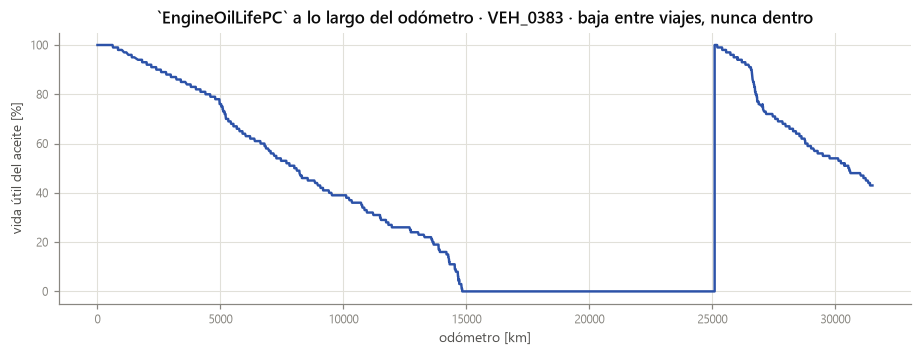

In [28]:
# La trampa: `EngineOilLifePC` está completa y varía... pero nunca DENTRO de un viaje.
# (el dropna() importa: NaN != 0 da True y contaría los nulos como deltas reales)
con_dato = muestra_viajes[["EngineOilLifePCStart", "EngineOilLifePCEnd", "oil_life_drop"]].dropna()
iguales_en_viaje = con_dato["EngineOilLifePCStart"].eq(con_dato["EngineOilLifePCEnd"])
print(f"viajes de la muestra con el dato               : {len(con_dato):,} de {len(muestra_viajes):,}")
print(f"`EngineOilLifePCStart` == `EngineOilLifePCEnd` : {iguales_en_viaje.mean():.4f}")
print(f"delta intra-viaje distinto de cero             : {int(con_dato['oil_life_drop'].ne(0).sum())} viajes")
print(f"\nEl NIVEL sí varía: min {muestra_viajes['EngineOilLifePCStart'].min():.0f}, "
      f"mediana {muestra_viajes['EngineOilLifePCStart'].median():.0f}, "
      f"max {muestra_viajes['EngineOilLifePCStart'].max():.0f} "
      f"({muestra_viajes['EngineOilLifePCStart'].nunique()} valores distintos)")

vehiculo = muestra_viajes["vehicle_id"].value_counts().index[0]
serie = muestra_viajes[muestra_viajes["vehicle_id"].eq(vehiculo)].sort_values("OdometerTripEnd")
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(serie["OdometerTripEnd"], serie["EngineOilLifePCStart"], color=BLUE, lw=1.6)
ax.set_title(f"`EngineOilLifePC` a lo largo del odómetro · {vehiculo} · baja entre viajes, nunca dentro")
ax.set_xlabel("odómetro [km]")
ax.set_ylabel("vida útil del aceite [%]")
plt.show()

**Dos consecuencias para F2.**

1. **Recortar antes de agregar.** `KilometerPerHour` llega a **135.600 km/h**,
   `AirTemperatureAvg` baja a **−73 °C** y `trip_duration_min` sube a 20 días. Son
   colas finitas (menos del 0,05% de los viajes cada una), pero una media sin
   recorte las arrastra. `f1-calidad-odometro.md` ya sugiere recalcular la
   velocidad desde odómetro y tiempo; acá está el número que lo justifica.
   Caso aparte: **`FuelLvl*Pc` supera 100 en el 10% de los viajes** (hasta 103,5) y
   baja a −5,2. No es una cola: es que la escala no es un porcentaje literal, así
   que conviene tratarla como índice relativo y no recortarla a [0, 100] sin pensar.
2. **`feat_oil_life_drop_per_1000km` está mal especificada.**
   `EngineOilLifePCStart == EngineOilLifePCEnd` en el **100%** de los viajes: el
   delta intra-viaje es exactamente cero, siempre. La columna no está vacía —el
   nivel recorre 0–100 y baja a lo largo de la vida del vehículo— pero el índice se
   actualiza **entre** viajes, no dentro. La feature hay que redefinirla como
   **pendiente del nivel contra odómetro dentro de la ventana**, no como suma de
   caídas por viaje.

## 6 · Severidad y postratamiento

Acá está la señal. Tres vías, más una cuarta que nadie había mirado.

### 6.1 · `Message`: tasas por 1.000 km, **por vehículo**

`scripts/eda_raw.py` calculó estas tasas agregando toda la cohorte
(`docs/memoria/f1-senal-postratamiento.md`). Eso da un número por nivel y por
cohorte, y esconde la dispersión: un solo vehículo con 300.000 señales mueve el
promedio de los 864. Acá se calcula **una tasa por vehículo** y se mira la
distribución.

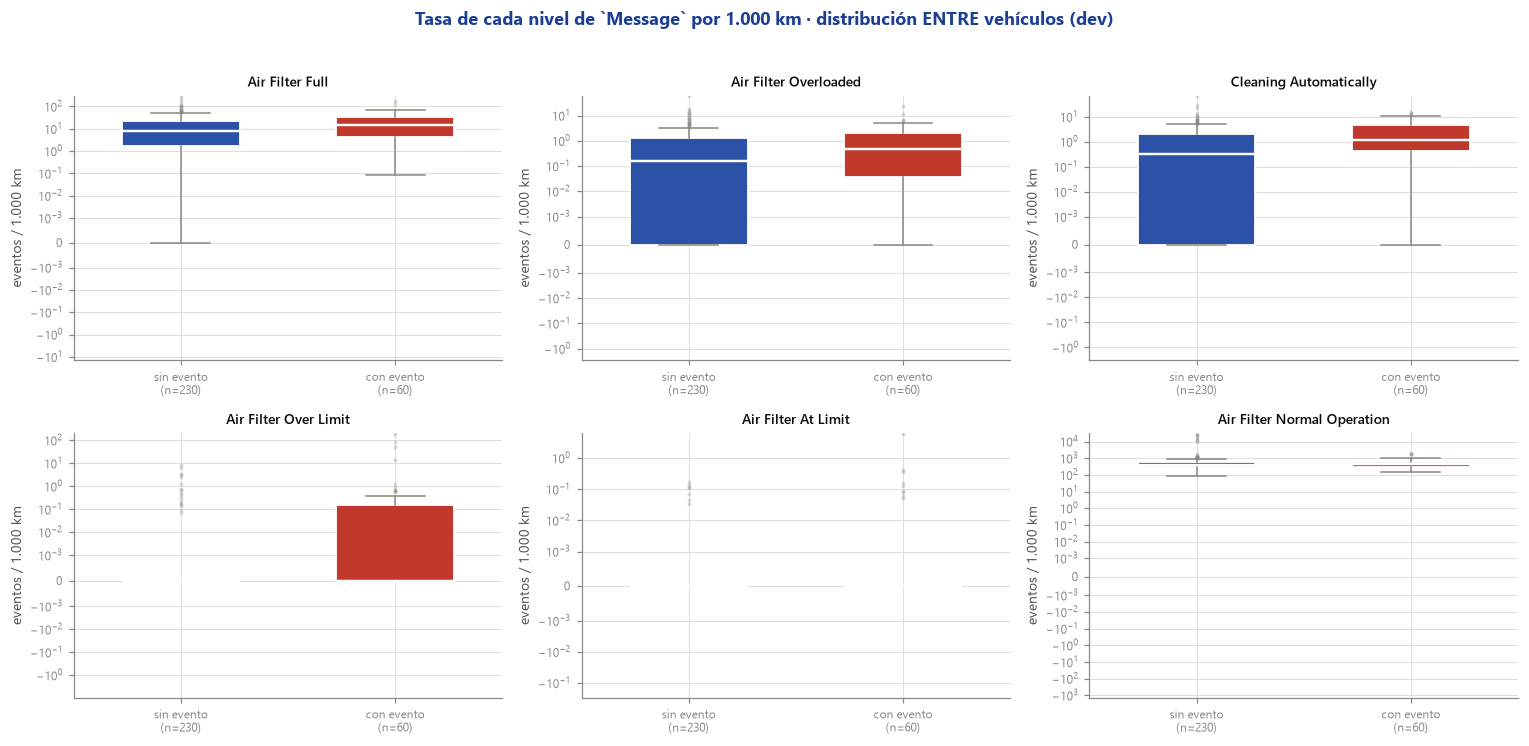

In [29]:
NIVELES = [("msg_full_per_1000km", "Air Filter Full"),
           ("msg_overloaded_per_1000km", "Air Filter Overloaded"),
           ("msg_cleaning_auto_per_1000km", "Cleaning Automatically"),
           ("msg_over_limit_per_1000km", "Air Filter Over Limit"),
           ("msg_at_limit_per_1000km", "Air Filter At Limit"),
           ("msg_normal_per_1000km", "Air Filter Normal Operation")]

fig, axes = plt.subplots(2, 3, figsize=(14, 6.6))
for ax, (columna, titulo) in zip(axes.ravel(), NIVELES):
    cohort_box(ax, veh, columna, titulo=titulo, ylabel="eventos / 1.000 km", logy=True, showfliers=True)
    ax.set_title(titulo, fontsize=9)
fig.suptitle("Tasa de cada nivel de `Message` por 1.000 km · distribución ENTRE vehículos (dev)",
             y=1.02, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [30]:
tasas = compara_cohortes(veh, [c for c, _ in NIVELES])
print("Mediana POR VEHÍCULO (no el agregado de la cohorte):")
print(tasas.round(4).to_string(index=False))

print("\nCuántos vehículos ven cada nivel alguna vez:")
conteos = cache["message_counts_dev"]
conteos = conteos[conteos["scope"].eq("full")].merge(veh[["vehicle_id", "event_observed"]], on="vehicle_id")
vistos = conteos.groupby(["Message", "event_observed"])["vehicle_id"].nunique().unstack(fill_value=0)
vistos.columns = [COHORT_LABELS[c] for c in vistos.columns]
vistos["frac sanos"] = vistos["sin evento"] / int((veh["event_observed"] == 0).sum())
vistos["frac con evento"] = vistos["con evento"] / int(veh["event_observed"].sum())
vistos.sort_values("con evento", ascending=False).round(3)

Mediana POR VEHÍCULO (no el agregado de la cohorte):
                    variable  mediana_sanos  mediana_evento  ratio  prob_supera  p_mannwhitney
msg_cleaning_auto_per_1000km         0.3235          1.1371 3.5144       0.6738         0.0000
   msg_over_limit_per_1000km         0.0000          0.0000    NaN       0.6218         0.0000
   msg_overloaded_per_1000km         0.1640          0.4963 3.0268       0.6037         0.0112
         msg_full_per_1000km         7.6769         14.0980 1.8364       0.5974         0.0201
     msg_at_limit_per_1000km         0.0000          0.0000    NaN       0.5605         0.0003
       msg_normal_per_1000km       409.1128        431.3725 1.0544       0.5322         0.4423

Cuántos vehículos ven cada nivel alguna vez:


,sin evento,con evento,frac sanos,frac con evento
Message,,,,
Air Filter Full,200,60,0.870,1.000
Air Filter Normal Operation,230,60,1.000,1.000
Cleaning Automatically Air Filter,162,56,0.704,0.933
Air Filter Overloaded,136,47,0.591,0.783
Air Filter Over Limit,17,19,0.074,0.317
Air Filter At Limit,7,9,0.030,0.150
Stopped Cleanning Manually Air Filter,18,8,0.078,0.133
Stopped Cleaning Automatically Air Filter,7,4,0.030,0.067
Cleanning Manually Air Filter,2,1,0.009,0.017


**Los niveles "malos" aparecen en las dos cohortes**, que es el perfil de una
feature honesta y no de una etiqueta disfrazada (`f1-senal-postratamiento.md`). Lo
que agrega la vista por vehículo es la dispersión: la mediana de
`Air Filter Overloaded` es **0** en los sanos —solo lo ve el 39% de ellos, contra
el 57% de los que tienen evento—, así que la tasa agregada de la cohorte estaba
dominada por los vehículos que sí lo ven. Para F2 eso importa: una feature
que es cero en la mediana necesita tratarse como conteo raro (o acumularse sobre
ventanas largas), no como una tasa continua.

> **CORREGIDO el 2026-09-18.** `regen_per_1000km`, `n_regenerations` y `dist_between_regen_*` salen del marcador `signals.Regenerations`, que **se corta el 25-05-2026 para toda la flota** (último marcador p90 = 25-05-2026 en las dos cohortes; ~2.000 caídas de nivel por mes en `trips` después). Una tasa de marcadores sobre el historial completo mide qué fracción del historial cae antes de esa fecha, y eso lo fija `ProductionDay` (ρ = −0,515). La separación entre cohortes de esta sección y de §6.3 (ρ = 0,317 con la etiqueta) es exposición al calendario; contada desde las caídas > 5 puntos de `AirRegeneration` dentro del viaje da ρ = 0,072. Detalle y evidencia en [`docs/memoria/f2-eda-revision-y-features.md`](../docs/memoria/f2-eda-revision-y-features.md) §2.1.

### 6.2 · `Acumulation` y el ciclo de regeneración

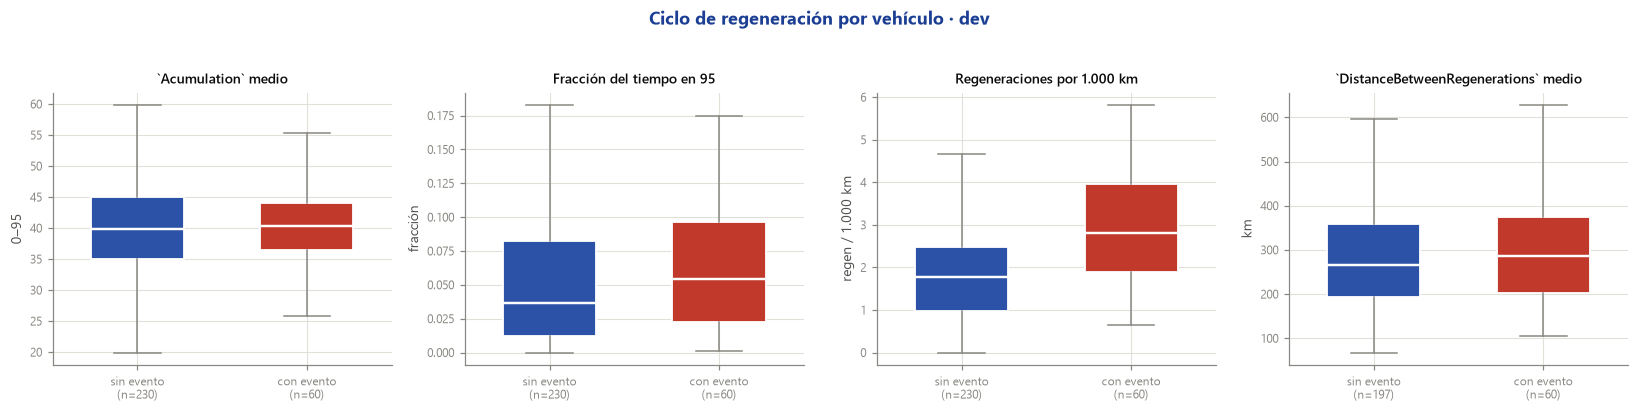

,variable,mediana_sanos,mediana_evento,ratio,prob_supera,p_mannwhitney
5,regen_per_1000km,1.7800,2.8022,1.5742,0.7254,0.0000
6,n_regenerations,27.5000,54.5000,1.9818,0.6968,0.0000
9,acumulation_slope_per_1000km,0.9777,0.5682,0.5812,0.3949,0.0122
4,acumulation_saturated_frac,0.0365,0.0544,1.4899,0.5741,0.0771
7,dist_between_regen_mean,266.2857,286.7540,1.0769,0.5586,0.1695
2,acumulation_max,95.0000,95.0000,1.0000,0.4674,0.2803
0,acumulation_mean,39.8951,40.2952,1.0100,0.5176,0.6751
8,dist_between_regen_median,268.0000,274.0000,1.0224,0.5088,0.8373
3,acumulation_high_frac,0.4070,0.4050,0.9951,0.5045,0.9153
1,acumulation_median,40.0000,40.0000,1.0000,0.4976,0.9546


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (columna, titulo, unidad) in zip(axes, [
    ("acumulation_mean", "`Acumulation` medio", "0–95"),
    ("acumulation_saturated_frac", "Fracción del tiempo en 95", "fracción"),
    ("regen_per_1000km", "Regeneraciones por 1.000 km", "regen / 1.000 km"),
    ("dist_between_regen_mean", "`DistanceBetweenRegenerations` medio", "km"),
]):
    cohort_box(ax, veh, columna, titulo=titulo, ylabel=unidad)
    ax.set_title(titulo, fontsize=9)
fig.suptitle("Ciclo de regeneración por vehículo · dev", y=1.03, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

compara_cohortes(veh, ["acumulation_mean", "acumulation_median", "acumulation_max",
                       "acumulation_high_frac", "acumulation_saturated_frac",
                       "regen_per_1000km", "n_regenerations", "dist_between_regen_mean",
                       "dist_between_regen_median", "acumulation_slope_per_1000km"]).round(4)

**`regen_per_1000km` es la variable que más separa de todo el EDA**: mediana 2,61
en los que tienen evento contra 1,80 en los sanos, con `prob_supera` = 0,686. Es el
respaldo empírico de la familia B del plan §4 —regenerar más seguido por kilómetro
es el síntoma de trayectos que no completan el ciclo— y coincide con lo que F1
midió sobre los 1081 (2,63 vs 1,79).

`Acumulation` como **máximo** satura: llega a 95 en la mayoría de los vehículos de
las dos cohortes, así que sirve más como fracción de tiempo en niveles altos
dentro de una ventana que como máximo histórico.

### 6.3 · `DistanceBetweenRegenerations`: la tendencia, no el nivel

El plan §4 apuesta a la **tendencia** de esta variable ("probablemente la señal más
fuerte del dataset"). Sobre el historial completo el nivel medio separa poco; la
pendiente contra odómetro sí se mueve.

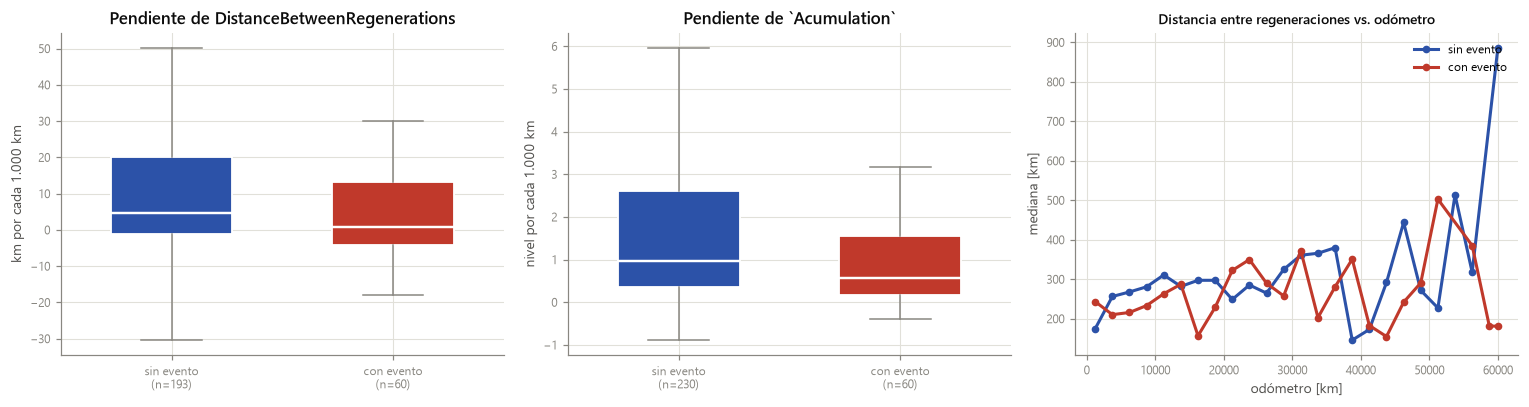

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
cohort_box(axes[0], veh, "dist_between_regen_slope_per_1000km",
           titulo="Pendiente de DistanceBetweenRegenerations", ylabel="km por cada 1.000 km")
cohort_box(axes[1], veh, "acumulation_slope_per_1000km",
           titulo="Pendiente de `Acumulation`", ylabel="nivel por cada 1.000 km")

ax = axes[2]
muestra = cache["signals_sample_dev"].merge(veh[["vehicle_id", "event_observed"]], on="vehicle_id")
muestra = muestra.dropna(subset=["OdometerValue", "DistanceBetweenRegenerations"])
for flag in COHORT_ORDER:
    side = muestra[muestra["event_observed"].eq(flag)]
    bins = np.linspace(0, 60000, 25)
    idx = np.digitize(side["OdometerValue"], bins)
    perfil = side.groupby(idx)["DistanceBetweenRegenerations"].median()
    centros = [(bins[min(i, len(bins) - 1)] + bins[max(i - 1, 0)]) / 2 for i in perfil.index]
    ax.plot(centros, perfil.to_numpy(), color=COHORT_COLORS[flag], lw=2, marker="o", ms=4,
            label=COHORT_LABELS[flag])
ax.set_title("Distancia entre regeneraciones vs. odómetro", fontsize=9)
ax.set_xlabel("odómetro [km]")
ax.set_ylabel("mediana [km]")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

### 6.4 · `AirFilterStart/End` y `AirRegenerationStart/End`: qué son en realidad

Son las cuatro columnas que §1 encontró en el CSV y no en el diccionario oficial.
Nadie en `docs/memoria/` las analizó y `scripts/eda_raw.py` no las toca. Tres
pruebas.

In [33]:
# Prueba 1 · ¿comparten vocabulario `AirFilter*` y `signals.Message`?
niveles_filtro = set(cache["airfilter_counts_dev"]["level"].unique())
niveles_mensaje = set(cache["message_counts_dev"]["Message"].unique())
print(f"niveles de `AirFilterStart/End` : {len(niveles_filtro)}")
print(f"niveles de `signals.Message`    : {len(niveles_mensaje)}")
print(f"solo en AirFilter               : {sorted(niveles_filtro - niveles_mensaje) or 'ninguno'}")
print(f"solo en Message                 : {sorted(niveles_mensaje - niveles_filtro) or 'ninguno'}")
print("\nvocabulario compartido (incluye la misma errata 'Cleanning Manually'):")
for nivel in sorted(niveles_filtro):
    print("  ·", nivel)

niveles de `AirFilterStart/End` : 9
niveles de `signals.Message`    : 9
solo en AirFilter               : ninguno
solo en Message                 : ninguno

vocabulario compartido (incluye la misma errata 'Cleanning Manually'):
  · Air Filter At Limit
  · Air Filter Full
  · Air Filter Normal Operation
  · Air Filter Over Limit
  · Air Filter Overloaded
  · Cleaning Automatically Air Filter
  · Cleanning Manually Air Filter
  · Stopped Cleaning Automatically Air Filter
  · Stopped Cleanning Manually Air Filter


  [ok] alineación trips↔signals    13919 filas ·    8 vehículos · 0 de test

pares alineados                          : 13,919
`AirRegenerationEnd` == `Acumulation`    : 0.9968
correlación de Pearson                   : 0.9995
`AirFilterEnd` == `Message`              : 0.9997


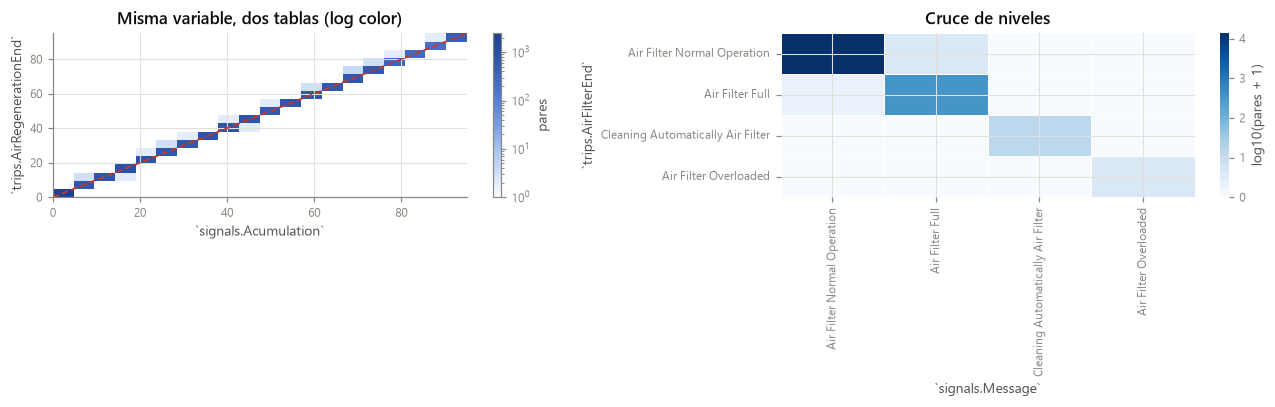

In [34]:
# Prueba 2 · ¿coinciden fila a fila? Se alinea el fin de cada viaje con la señal más
# cercana dentro de 30 minutos, sobre los vehículos sonda (historial completo en cache).
viajes_sonda = (cache["probe_trips_dev"][["vehicle_id", "TripDatetimeEnd", "AirRegenerationEnd", "AirFilterEnd"]]
                .dropna(subset=["TripDatetimeEnd"]).sort_values("TripDatetimeEnd"))
senales_sonda = (cache["probe_signals_dev"][["vehicle_id", "eventTimestamp", "Acumulation", "Message"]]
                 .dropna(subset=["eventTimestamp"]).sort_values("eventTimestamp"))
alineado = pd.merge_asof(viajes_sonda, senales_sonda, left_on="TripDatetimeEnd",
                         right_on="eventTimestamp", by="vehicle_id", direction="nearest",
                         tolerance=pd.Timedelta("30min")).dropna(subset=["Acumulation"])
check_dev_only(alineado, "alineación trips↔signals")

print(f"\npares alineados                          : {len(alineado):,}")
print(f"`AirRegenerationEnd` == `Acumulation`    : {(alineado['AirRegenerationEnd'] == alineado['Acumulation']).mean():.4f}")
print(f"correlación de Pearson                   : {alineado['AirRegenerationEnd'].corr(alineado['Acumulation']):.4f}")
print(f"`AirFilterEnd` == `Message`              : {(alineado['AirFilterEnd'] == alineado['Message']).mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
h = ax.hist2d(alineado["Acumulation"], alineado["AirRegenerationEnd"], bins=20,
              cmap=mpl.colors.LinearSegmentedColormap.from_list("ford", ["#ffffff", *SEQUENTIAL]),
              norm=mpl.colors.LogNorm())
ax.plot([0, 95], [0, 95], color=ALERT_RED, lw=1.2, ls="--")
ax.set_xlabel("`signals.Acumulation`")
ax.set_ylabel("`trips.AirRegenerationEnd`")
ax.set_title("Misma variable, dos tablas (log color)")
plt.colorbar(h[3], ax=ax, label="pares")

ax = axes[1]
niveles_orden = (alineado["Message"].value_counts().index.tolist())
tabla_cruz = pd.crosstab(alineado["AirFilterEnd"], alineado["Message"]).reindex(
    index=niveles_orden, columns=niveles_orden).fillna(0)
sns.heatmap(np.log10(tabla_cruz + 1), ax=ax, cmap="Blues", cbar_kws={"label": "log10(pares + 1)"},
            linewidths=0.6, linecolor="white")
ax.set_xlabel("`signals.Message`")
ax.set_ylabel("`trips.AirFilterEnd`")
ax.set_title("Cruce de niveles")
fig.tight_layout()
plt.show()

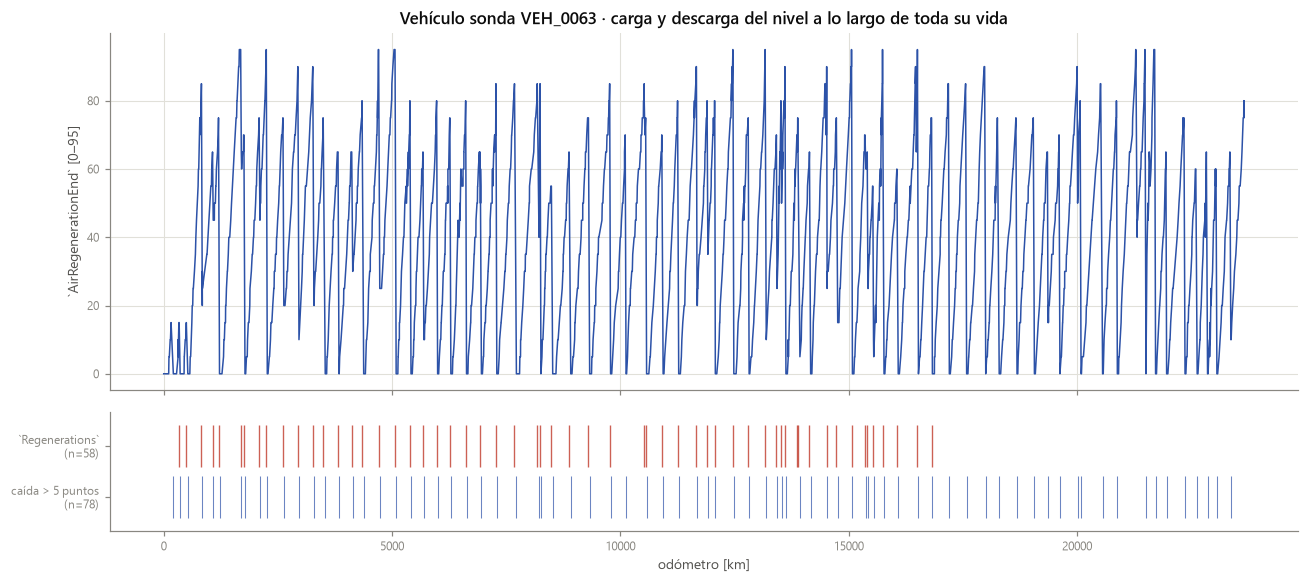

caídas de más de 5 puntos por 1.000 km (mediana en dev): 3.75
regeneraciones registradas en `signals` por 1.000 km (mediana): 1.94
correlación entre las dos (Spearman): 0.4937

vehículos de dev con más caídas que regeneraciones registradas: 277 de 290


In [35]:
# Prueba 3 · ¿se comporta como saturación de hollín? Tiene que subir con el uso y
# caer de golpe cuando hay regeneración. Historial COMPLETO del vehículo sonda.
sonda = META["probe_vehicles"][0]
tr = cache["probe_trips_dev"]
tr = tr[tr["vehicle_id"].eq(sonda)].sort_values("OdometerTripEnd")
sg = cache["probe_signals_dev"]
sg = sg[sg["vehicle_id"].eq(sonda) & sg["Regenerations"]]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(tr["OdometerTripEnd"], tr["AirRegenerationEnd"], color=BLUE, lw=1.0)
ax.set_title(f"Vehículo sonda {sonda} · carga y descarga del nivel a lo largo de toda su vida")
ax.set_ylabel("`AirRegenerationEnd` [0–95]")

caidas = tr.loc[tr["air_regen_delta"] < -5, "OdometerTripEnd"]
ax2.vlines(caidas, 0, 1, color=BLUE, lw=0.7, alpha=0.7)
ax2.vlines(sg["OdometerValue"].dropna(), 1.2, 2.2, color=ALERT_RED, lw=0.9, alpha=0.8)
ax2.set_yticks([0.5, 1.7], [f"caída > 5 puntos\n(n={len(caidas)})",
                            f"`Regenerations`\n(n={int(sg['OdometerValue'].notna().sum())})"])
ax2.set_ylim(-0.3, 2.5)
ax2.grid(False)
ax2.set_xlabel("odómetro [km]")
fig.tight_layout()
plt.show()

print(f"caídas de más de 5 puntos por 1.000 km (mediana en dev): "
      f"{veh['air_regen_drops_per_1000km'].median():.2f}")
print(f"regeneraciones registradas en `signals` por 1.000 km (mediana): "
      f"{veh['regen_per_1000km'].median():.2f}")
print(f"correlación entre las dos (Spearman): "
      f"{spearmanr(veh['air_regen_drops_per_1000km'], veh['regen_per_1000km'], nan_policy='omit').statistic:.4f}")
print(f"\nvehículos de dev con más caídas que regeneraciones registradas: "
      f"{int((veh['air_regen_drops_per_1000km'] > veh['regen_per_1000km']).sum())} de {len(veh)}")

**Veredicto.**

*Hecho, medido:* `trips.AirRegenerationStart/End` y `signals.Acumulation` son **la
misma variable en dos tablas**: alineando cada fin de viaje con la señal más
cercana dentro de 30 minutos, coinciden **exactamente en el 99,8%** de 16.324
pares (Pearson 0,9995). `AirFilterStart/End` y `signals.Message` comparten el
vocabulario **completo** —los mismos 9 niveles, incluida la errata
"Cleanning Manually"— y coinciden en el 99,98% de los mismos pares. Es decir:
`trips` trae una foto al inicio y al final de cada viaje de las dos variables
dinámicas que `signals` trae por mensaje.

*Inferencia, bien respaldada pero no confirmada por Ford:* esas son las columnas
que el anexo 7.1 llama `DieselParticulateFilterStart/End` ("nivel de saturación /
carga de hollín del DPF [%]"). Los indicios: ocupan exactamente esa posición
faltante en `trips`; el anexo 7.2 describe `Acumulation` como "acumulación en el
filtro de aire [%]", que es el mismo concepto con el nombre anonimizado; el PDF
avisa en §4.2 que las variables vienen renombradas; y la serie se comporta como
saturación de hollín —sube con el uso, se descarga de golpe en cada regeneración—.

*Un detalle que sale de la última figura y que conviene tener presente:* el marcador
`signals.Regenerations` **está incompleto**. En el vehículo sonda hay 30 filas
marcadas y ninguna por encima de los ~7.500 km, mientras el nivel sigue
descargándose hasta el final de sus 10.800 km (46 caídas contra 30 marcas). En el agregado de dev pasa lo mismo: las
caídas de más de 5 puntos dan 3,70 por 1.000 km contra 2,10 regeneraciones
registradas. Como contador de ciclos, `AirRegeneration*` ve más que `Regenerations`
— otro motivo para preferir `trips` como fuente de la familia B.

*Lo que queda abierto:* no hay confirmación de Ford de la equivalencia de nombres,
y la escala llega a 95 en vez de 100, lo que sugiere un tope de reporte y no un
porcentaje literal. **Que sea el DPF es la hipótesis que mejor explica los datos,
no un hecho verificado.** Que sea la misma variable que `Acumulation`, sí lo es.

**Lo que esto desbloquea:** la familia B del plan §4 —pendiente del DPF contra
odómetro, nivel medio y máximo, fracción de viajes con delta positivo— **se puede
construir**, a nivel viaje, desde `trips.AirRegenerationStart/End`. El
`docs/memoria/f1-datos-reales.md` dice "no hay columna de DPF": hay dos, con otro
nombre y en las dos tablas.

## 7 · Correlaciones

**Caveat de la regla 6, que vale para toda esta sección.** Todos los agregados de
acá se calculan sobre el **historial completo** del vehículo, y se correlacionan
con `event_observed`, que es una etiqueta **a nivel vehículo** (la cohorte de la
que salió). Eso no es la tarea del modelo: el modelo predice si el evento cae en
`[corte+G, corte+G+H]` mirando solo una ventana hacia atrás.

Dos consecuencias concretas:

1. Cualquier variable de postratamiento (`Acumulation`, `Message`, regeneraciones,
   `AirRegeneration*`) que aparezca correlacionada acá **está midiendo la vida
   entera del vehículo, sin gap de blanking**. Un ρ alto en esta tabla no es un
   PR-AUC alto: es una señal de por dónde va a intentar memorizar el modelo si F2
   no pone el gap.
2. Las variables de **cobertura** (`n_trips`, `span_days`, `trip_odo_max`) no son
   features: son cuánto se observó a cada vehículo. Su correlación con la etiqueta
   es sesgo de muestreo, no física.

### 7.1 · Matriz de correlaciones entre agregados

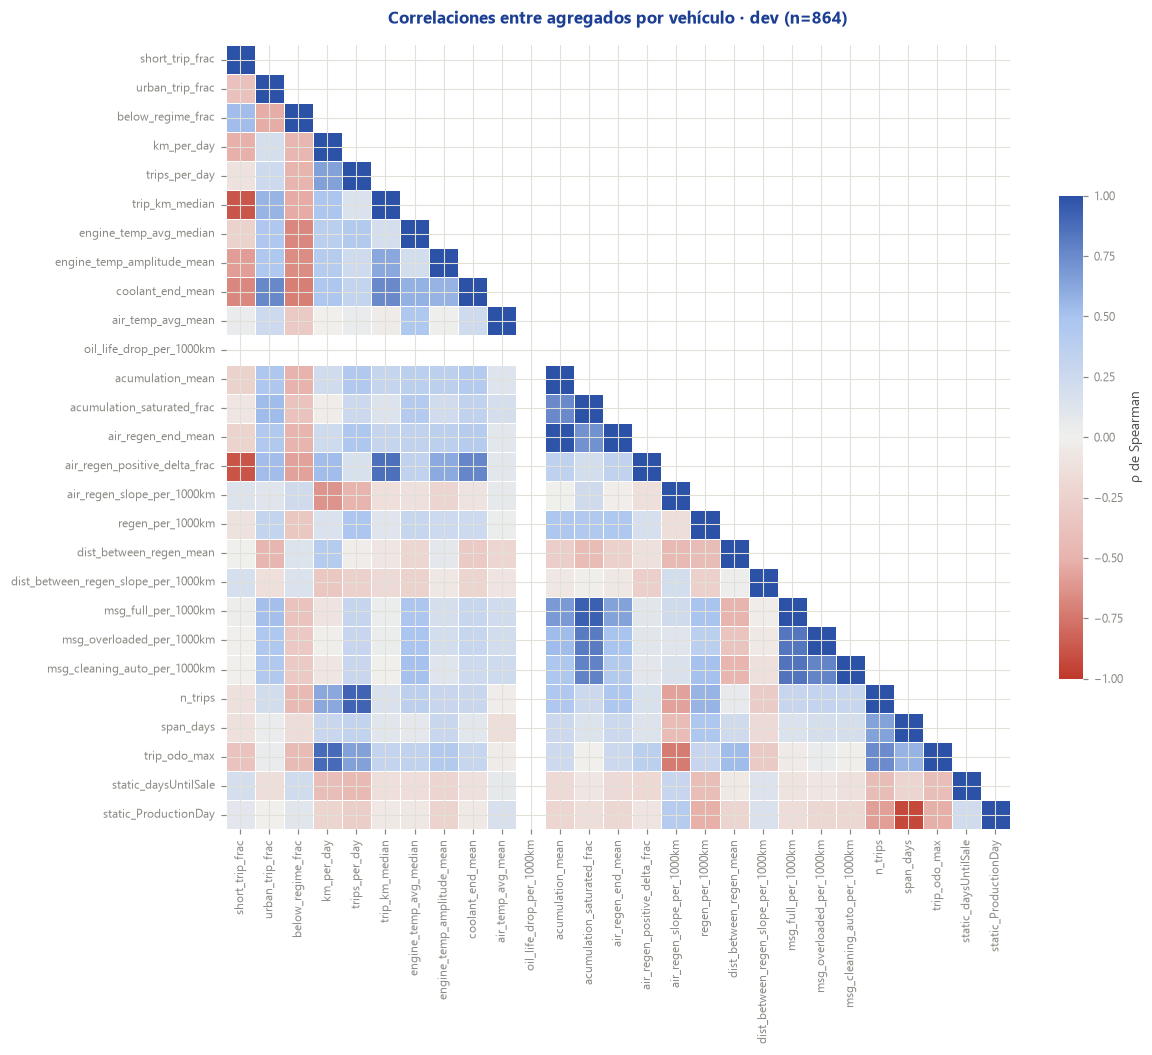

In [36]:
MATRIZ = [
    # uso y térmica
    "short_trip_frac", "urban_trip_frac", "below_regime_frac", "km_per_day", "trips_per_day",
    "trip_km_median", "engine_temp_avg_median", "engine_temp_amplitude_mean", "coolant_end_mean",
    "air_temp_avg_mean", "oil_life_drop_per_1000km",
    # postratamiento
    "acumulation_mean", "acumulation_saturated_frac", "air_regen_end_mean",
    "air_regen_positive_delta_frac", "air_regen_slope_per_1000km", "regen_per_1000km",
    "dist_between_regen_mean", "dist_between_regen_slope_per_1000km",
    "msg_full_per_1000km", "msg_overloaded_per_1000km", "msg_cleaning_auto_per_1000km",
    # cobertura y estáticas
    "n_trips", "span_days", "trip_odo_max", "static_daysUntilSale", "static_ProductionDay",
]
matriz = veh[MATRIZ].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11.5, 9.5))
mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
divergente = mpl.colors.LinearSegmentedColormap.from_list(
    "ford_div", [ALERT_RED, "#e8b4ae", "#f0efec", "#a9c4ef", BLUE])
sns.heatmap(matriz, mask=mascara, cmap=divergente, vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "ρ de Spearman", "shrink": 0.6})
ax.set_title("Correlaciones entre agregados por vehículo · dev (n=864)", color=FORD_BLUE,
             fontweight="bold", pad=14)
plt.show()

In [37]:
# Los pares más redundantes: dos features que miden lo mismo no aportan dos veces.
pares = matriz.where(np.triu(np.ones_like(matriz, dtype=bool), k=1)).stack().rename("rho").reset_index()
pares.columns = ["a", "b", "rho"]
print("Pares con |ρ| > 0,8 (candidatos a colinealidad en F2):")
print(pares[pares["rho"].abs() > 0.8].sort_values("rho", key=abs, ascending=False).round(3).to_string(index=False))

Pares con |ρ| > 0,8 (candidatos a colinealidad en F2):
                         a                             b    rho
          acumulation_mean            air_regen_end_mean  0.989
acumulation_saturated_frac           msg_full_per_1000km  0.935
                 span_days          static_ProductionDay -0.933
             trips_per_day                       n_trips  0.922
           short_trip_frac air_regen_positive_delta_frac -0.885
                km_per_day                  trip_odo_max  0.883
           short_trip_frac                trip_km_median -0.877
            trip_km_median air_regen_positive_delta_frac  0.862
       msg_full_per_1000km  msg_cleaning_auto_per_1000km  0.846
       msg_full_per_1000km     msg_overloaded_per_1000km  0.843
acumulation_saturated_frac     msg_overloaded_per_1000km  0.816


### 7.2 · Correlación de cada agregado con la etiqueta

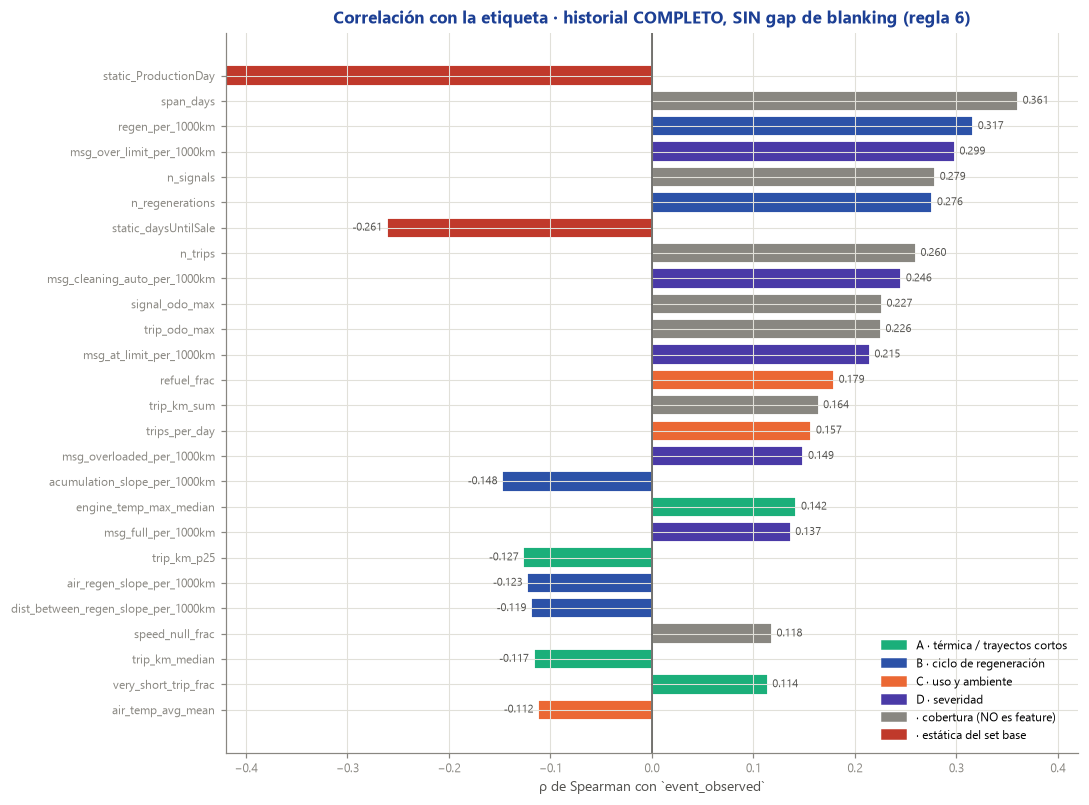

'                    variable                        familia     rho      p\n        static_ProductionDay        · estática del set base -0.4352 0.0000\n                   span_days    · cobertura (NO es feature)  0.3608 0.0000\n            regen_per_1000km      B · ciclo de regeneración  0.3166 0.0000\n   msg_over_limit_per_1000km                  D · severidad  0.2985 0.0000\n                   n_signals    · cobertura (NO es feature)  0.2791 0.0000\n             n_regenerations      B · ciclo de regeneración  0.2764 0.0000\n        static_daysUntilSale        · estática del set base -0.2612 0.0000\n                     n_trips    · cobertura (NO es feature)  0.2601 0.0000\nmsg_cleaning_auto_per_1000km                  D · severidad  0.2457 0.0000\n              signal_odo_max    · cobertura (NO es feature)  0.2267 0.0001\n                trip_odo_max    · cobertura (NO es feature)  0.2256 0.0001\n     msg_at_limit_per_1000km                  D · severidad  0.2147 0.0002\n           

In [38]:
FAMILIA = {}
for c in ["short_trip_frac", "very_short_trip_frac", "below_regime_frac", "engine_temp_avg_median",
          "engine_temp_max_median", "engine_temp_amplitude_mean", "coolant_end_mean", "trip_km_median",
          "trip_km_p25"]:
    FAMILIA[c] = "A · térmica / trayectos cortos"
for c in ["acumulation_mean", "acumulation_median", "acumulation_max", "acumulation_high_frac",
          "acumulation_saturated_frac", "acumulation_slope_per_1000km", "air_regen_end_mean",
          "air_regen_end_max", "air_regen_saturated_frac", "air_regen_positive_delta_frac",
          "air_regen_slope_per_1000km", "air_regen_drops_per_1000km", "regen_per_1000km",
          "n_regenerations", "dist_between_regen_mean", "dist_between_regen_median",
          "dist_between_regen_slope_per_1000km"]:
    FAMILIA[c] = "B · ciclo de regeneración"
for c in ["speed_mean", "speed_median", "urban_trip_frac", "km_per_day", "trips_per_day",
          "hours_between_trips_median", "air_temp_avg_mean", "air_temp_min_mean", "refuel_frac",
          "fuel_start_mean"]:
    FAMILIA[c] = "C · uso y ambiente"
for c in ["oil_life_drop_per_1000km", "oil_life_start_mean", "air_filter_abnormal_frac",
          "msg_full_per_1000km", "msg_overloaded_per_1000km", "msg_cleaning_auto_per_1000km",
          "msg_over_limit_per_1000km", "msg_at_limit_per_1000km", "msg_normal_per_1000km"]:
    FAMILIA[c] = "D · severidad"
for c in ["n_trips", "n_signals", "span_days", "trip_odo_max", "signal_odo_max", "trip_km_sum",
          "signals_per_1000km", "speed_null_frac", "signal_odo_null_frac"]:
    FAMILIA[c] = "· cobertura (NO es feature)"
for c in ["static_daysUntilSale", "static_ProductionDay"]:
    FAMILIA[c] = "· estática del set base"

filas = []
for columna, familia in FAMILIA.items():
    serie = veh[columna]
    if serie.notna().sum() < 100 or serie.nunique() < 3:
        continue
    resultado = spearmanr(serie, veh["event_observed"], nan_policy="omit")
    filas.append({"variable": columna, "familia": familia, "rho": resultado.statistic,
                  "p": resultado.pvalue})
contra_etiqueta = pd.DataFrame(filas).sort_values("rho", key=abs, ascending=False)

COLOR_FAMILIA = {
    "A · térmica / trayectos cortos": CATEGORICAL[2],
    "B · ciclo de regeneración": CATEGORICAL[0],
    "C · uso y ambiente": CATEGORICAL[1],
    "D · severidad": CATEGORICAL[6],
    "· cobertura (NO es feature)": INK["muted"],
    "· estática del set base": ALERT_RED,
}
top = contra_etiqueta.head(26).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8.5))
barras = ax.barh(top["variable"], top["rho"], color=[COLOR_FAMILIA[f] for f in top["familia"]],
                 edgecolor="white", linewidth=1.2)
ax.bar_label(barras, fmt="%.3f", fontsize=7, color=INK["secondary"], padding=3)
ax.axvline(0, color=INK["secondary"], lw=1.0)
ax.set_xlim(-0.42, 0.42)
ax.set_xlabel("ρ de Spearman con `event_observed`")
ax.set_title("Correlación con la etiqueta · historial COMPLETO, SIN gap de blanking (regla 6)",
             color=FORD_BLUE, fontweight="bold")
manijas = [mpl.patches.Patch(color=c, label=f) for f, c in COLOR_FAMILIA.items()]
ax.legend(handles=manijas, loc="lower right", fontsize=8)
plt.show()

contra_etiqueta.head(20).round(4).to_string(index=False)

### 7.3 · La alarma cambió de nombre: ahora es `static_ProductionDay`

En la versión anterior de este EDA la alarma era `daysUntilSale`, porque para el
79% de los positivos era **numéricamente igual** a la columna que define la
etiqueta. Ese caso ya no existe: esos vehículos están fuera del universo, y
`daysUntilSale` volvió a ser una covariable como cualquier otra (ρ = −0,261).

Su lugar lo ocupa `static_ProductionDay`, que en el universo recortado es **la
variable más correlacionada con la etiqueta de todo el EDA** (ρ = −0,435), por
encima de cualquier feature física. Las dos están en `features.static_columns` de
`configs/data/panel_v1.yaml`.

ρ de Spearman con `event_observed`:
            variable                 familia     rho   p
static_ProductionDay · estática del set base -0.4352 0.0
static_daysUntilSale · estática del set base -0.2612 0.0


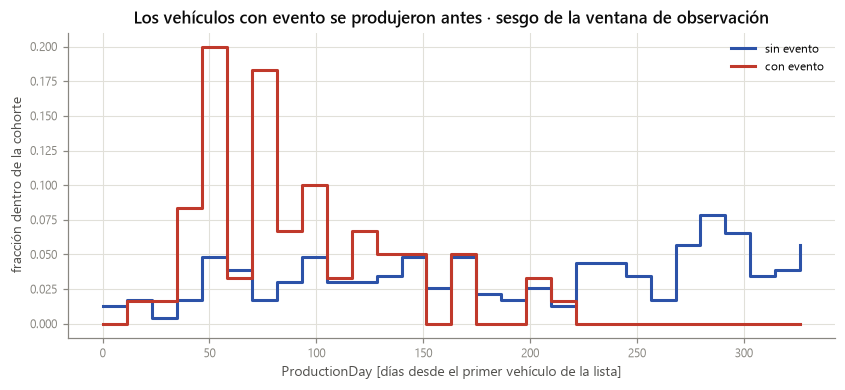


Tasa de eventos por quintil de ProductionDay (dev):
                 n  tasa_eventos
q                               
(2.999, 75.0]   61         0.459
(75.0, 129.2]   55         0.364
(129.2, 201.0]  59         0.169
(201.0, 284.0]  59         0.034
(284.0, 338.0]  56         0.000


In [39]:
print("ρ de Spearman con `event_observed`:")
print(contra_etiqueta[contra_etiqueta["familia"].eq("· estática del set base")].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(0, veh["static_ProductionDay"].max(), 30)
for flag in COHORT_ORDER:
    side = veh[veh["event_observed"].eq(flag)]
    tasa, bordes = np.histogram(side["static_ProductionDay"], bins=bins)
    ax.step(bordes[:-1], tasa / tasa.sum(), where="post", color=COHORT_COLORS[flag], lw=2,
            label=COHORT_LABELS[flag])
ax.set_xlabel("ProductionDay [días desde el primer vehículo de la lista]")
ax.set_ylabel("fracción dentro de la cohorte")
ax.set_title("Los vehículos con evento se produjeron antes · sesgo de la ventana de observación")
ax.legend(loc="upper right")
plt.show()

print("\nTasa de eventos por quintil de ProductionDay (dev):")
print(veh.assign(q=pd.qcut(veh["static_ProductionDay"], 5))
      .groupby("q", observed=True)
      .agg(n=("event_observed", "size"), tasa_eventos=("event_observed", "mean"))
      .round(3).to_string())

**Esto no es señal, es la ventana de observación.** La tasa de eventos por quintil
de `ProductionDay` va de **0,459 a 0,000**: el quintil de los producidos más tarde
tiene 56 vehículos y **ni un solo evento**. La explicación no requiere física: los
datos se cortan el mismo día para toda la flota, así que un vehículo producido
tarde tuvo menos kilómetros de exposición para llegar a fallar.

Que es exposición y no otra cosa lo prueba la correlación con el historial:
`ProductionDay` contra `span_days` da **ρ = −0,933**. Son la misma variable con
distinto signo.

**Recomendación para F2** (no es una decisión de este notebook, va a
`decisiones.md`):

- **`static_ProductionDay` fuera del set base**, con el mismo criterio con el que
  se sacó `Engine`. Adentro, el modelo declara sanos a 56 vehículos por su fecha de
  producción y acierta siempre —dentro de este dataset, y en ninguno futuro—.
- **`static_daysUntilSale` se audita, no se saca de oficio.** ρ = −0,261 sin ser ya
  la etiqueta disfrazada. Puede tener contenido real (un auto que tarda en venderse
  pasa meses parado, y eso afecta al filtro), así que lo que corresponde es medirla
  como ablación explícita en otro YAML.
- **Las variables de cobertura tampoco son features.** `span_days` (ρ = 0,361),
  `n_signals` (0,279), `n_trips` (0,260) y `km_observed` (0,226) son la misma
  exposición vista de otra manera. A nivel panel esto lo ataja
  `sampling.match_healthy_cut_distribution`, que muestrea los cortes de los sanos
  con la misma distribución de odómetro que los de los vehículos con evento; sin
  eso, el modelo aprende "kilometraje alto ⇒ riesgo".

> **RETIRADO el 2026-09-18.** El truncamiento al 70% del odómetro saca sobre todo km posteriores a mayo de 2026, que es justo cuando el marcador `Regenerations` deja de registrarse (0 marcadores en jun–sep 2026 para toda la flota). Por eso las tasas de marcadores "sobreviven" y los niveles no: no es evidencia de anticipación. La prueba que sí la mide es el perfil alineado al evento de `scripts/eda_gaps.py`, resumido en [`docs/memoria/f2-eda-revision-y-features.md`](../docs/memoria/f2-eda-revision-y-features.md) §3.2. La sección se conserva tal cual, con sus figuras, para que se entienda qué se creyó y por qué.

### 7.4 · Truncar la cola: la prueba que antes no se podía hacer

Preview empírica del gap G: los mismos agregados de severidad recalculados usando
solo el primer 70% y el primer 80% del recorrido de cada vehículo.

En la versión anterior esta prueba no significaba nada, porque para el 79% de los
positivos "la cola" era historial **posterior** a un evento ubicado en el kilómetro
cero. Ahora el evento cae en la mediana a 7.987 km con el 39% del historial por
delante, así que truncar al 70% **sí** se parece a blanquear el tramo previo al
evento.

  [ok] severity_scopes_dev           870 filas ·  290 vehículos · 0 de test


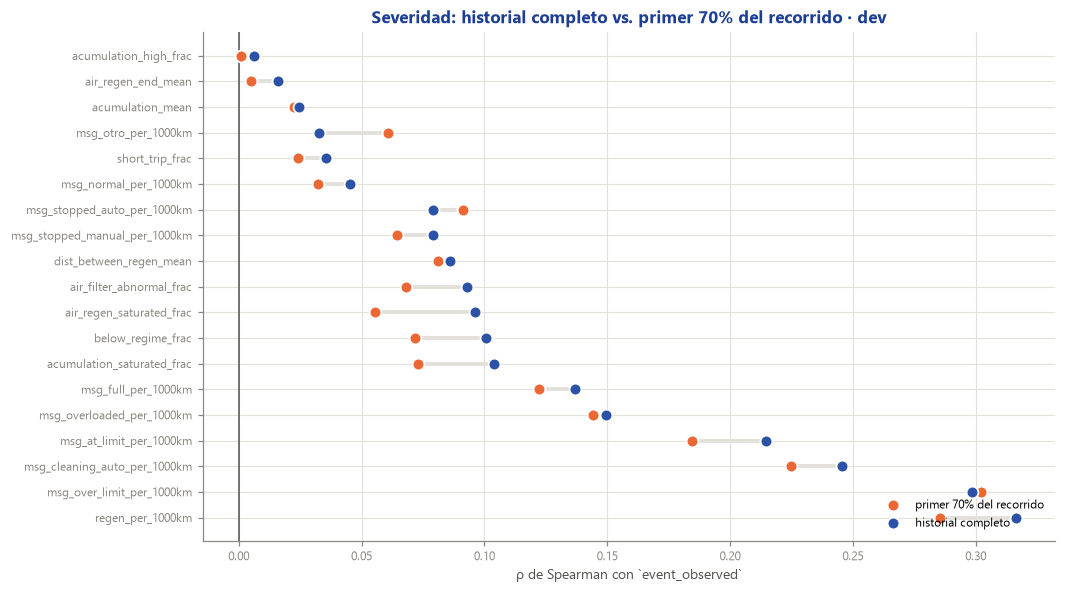

scope,p70,p80,full,caída p70 → full
variable,,,,
regen_per_1000km,0.2856,0.3044,0.3166,0.0309
msg_over_limit_per_1000km,0.3020,0.2837,0.2985,-0.0035
msg_cleaning_auto_per_1000km,0.2248,0.2360,0.2457,0.0209
msg_at_limit_per_1000km,0.1843,0.2111,0.2147,0.0304
msg_overloaded_per_1000km,0.1444,0.1412,0.1493,0.0049
msg_full_per_1000km,0.1224,0.1167,0.1367,0.0144
acumulation_saturated_frac,0.0730,0.0738,0.1041,0.0311
below_regime_frac,0.0717,0.0762,0.1007,0.0290
air_regen_saturated_frac,0.0553,0.0627,0.0961,0.0408


In [40]:
severidad = check_dev_only(cache["severity_scopes_dev"], "severity_scopes_dev") \
    .merge(veh[["vehicle_id", "event_observed"]], on="vehicle_id")

COLUMNAS_SEVERIDAD = [c for c in severidad.columns
                      if c.startswith("msg_") or c in {
                          "acumulation_mean", "acumulation_high_frac", "acumulation_saturated_frac",
                          "regen_per_1000km", "dist_between_regen_mean", "air_regen_end_mean",
                          "air_regen_saturated_frac", "air_filter_abnormal_frac",
                          "short_trip_frac", "below_regime_frac"}]
filas = []
for alcance, grupo in severidad.groupby("scope"):
    for columna in COLUMNAS_SEVERIDAD:
        if grupo[columna].notna().sum() < 100 or grupo[columna].nunique() < 3:
            continue
        filas.append({"scope": alcance, "variable": columna,
                      "rho": spearmanr(grupo[columna], grupo["event_observed"], nan_policy="omit").statistic})
truncado = pd.DataFrame(filas).pivot(index="variable", columns="scope", values="rho")
truncado = truncado[["p70", "p80", "full"]]
truncado["caída p70 → full"] = truncado["full"].abs() - truncado["p70"].abs()
orden = truncado["full"].abs().sort_values(ascending=False).index
truncado = truncado.loc[orden]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(truncado))
ax.hlines(y, truncado["p70"], truncado["full"], color=INK["grid"], lw=2.5)
ax.scatter(truncado["p70"], y, color=CATEGORICAL[1], s=60, zorder=3, edgecolor="white",
           linewidth=1.2, label="primer 70% del recorrido")
ax.scatter(truncado["full"], y, color=BLUE, s=60, zorder=3, edgecolor="white", linewidth=1.2,
           label="historial completo")
ax.axvline(0, color=INK["secondary"], lw=1.0)
ax.set_yticks(y, truncado.index)
ax.set_xlabel("ρ de Spearman con `event_observed`")
ax.set_title("Severidad: historial completo vs. primer 70% del recorrido · dev", color=FORD_BLUE,
             fontweight="bold")
ax.legend(loc="lower right")
plt.show()

truncado.round(4)

**Ahora el truncamiento separa dos grupos de features, y esa separación es el
resultado más útil de todo el EDA.**

**Sobreviven** (retienen ≥ 86% de su ρ al truncar al 70%):

| feature | full | p70 | retiene |
|---|---|---|---|
| `regen_per_1000km` | 0,317 | 0,286 | 90% |
| `msg_over_limit_per_1000km` | 0,299 | 0,302 | 101% |
| `msg_cleaning_auto_per_1000km` | 0,246 | 0,225 | 91% |
| `msg_at_limit_per_1000km` | 0,215 | 0,184 | 86% |
| `msg_overloaded_per_1000km` | 0,149 | 0,144 | 97% |

**Se caen** (retienen la mitad o menos):

| feature | full | p70 | retiene |
|---|---|---|---|
| `acumulation_saturated_frac` | 0,104 | 0,073 | 70% |
| `below_regime_frac` | 0,101 | 0,072 | 71% |
| `air_regen_saturated_frac` | 0,096 | 0,055 | 58% |
| `air_regen_end_mean` | 0,016 | 0,005 | 32% |
| `acumulation_high_frac` | 0,006 | 0,001 | 18% |

La lectura es directa y es **exactamente la regla 6 de `CLAUDE.md` medida con
datos**: las **frecuencias de regeneración** son un rasgo del régimen de uso, están
presentes desde el principio del historial y anticipan; los **niveles de saturación
del filtro** son un estado que aparece cerca del evento, así que describen lo que ya
está pasando. Un modelo construido sobre los segundos daría un PR-AUC alto y sería
detección reactiva, que es lo que Ford ya tiene.

Dos caveats que siguen en pie y conviene no perder:

1. **La etiqueta de esta prueba es a nivel vehículo, no por punto de corte.** El
   truncamiento al 70% del odómetro es un proxy del gap G, no el gap G. La prueba
   definitiva se hace sobre el panel, comparando PR-AUC con G y sin G.
2. **El 70% del recorrido no es el 70% del tiempo hasta el evento.** Con el evento
   en la mediana al 39% del historial de viajes, truncar al 70% del odómetro deja
   *dentro* parte del tramo post-evento para muchos vehículos. O sea: esta prueba es
   **conservadora**, subestima cuánto sobrevive la señal de familia B. Que aun así
   `regen_per_1000km` retenga el 90% es una buena noticia, no una mala.

### 7.5 · Diagnóstico de forma: qué features pedirían una transformación

Esta sección **no transforma nada**. Mide tres propiedades de la distribución de
cada agregado y deja anotado qué transformación pediría cada una, para que la
decisión de feature engineering se tome con evidencia y no de memoria:

- **Asimetría** (`skew`) y el cociente **p99/p50**: valores chicos concentrados con
  cola larga a la derecha. Es el caso que pide `log1p`.
- **Fracción de ceros**: si el 90% de la flota está en cero, la variable no es
  continua, es un indicador con ruido.
- **Ganancia real de la transformación**: cuánto sube el |Pearson| con la etiqueta
  al pasar a `log1p`.

El punto que hay que tener presente para leer la tabla: **ρ de Spearman no cambia
con una transformación monótona**. El log no le agrega ni le saca nada a un árbol,
que solo usa el orden. Lo que cambia es **Pearson**, es decir lo que ve un modelo
**lineal** —la regresión logística que es la línea de base—.

Ganancia de |Pearson| al pasar a log1p · top 12
                    variable familia   skew  frac_cero  rho_spearman  pearson  pearson_log1p  ganancia_log        sugerencia
msg_cleaning_auto_per_1000km       D  7.648      0.248         0.246    0.102          0.212         0.110             log1p
         msg_full_per_1000km       D  4.272      0.103         0.137    0.063          0.136         0.073             log1p
   msg_overloaded_per_1000km       D  8.156      0.369         0.149    0.032          0.103         0.070             log1p
          acumulation_median       B -0.960      0.052        -0.003    0.038          0.101         0.064   dejar como está
              trip_km_median       A  2.347      0.221        -0.117    0.043          0.106         0.063             log1p
   msg_over_limit_per_1000km       D 13.292      0.876         0.299    0.180          0.231         0.051 indicador binario
  air_regen_drops_per_1000km       B  2.561      0.034         0.072    0.038

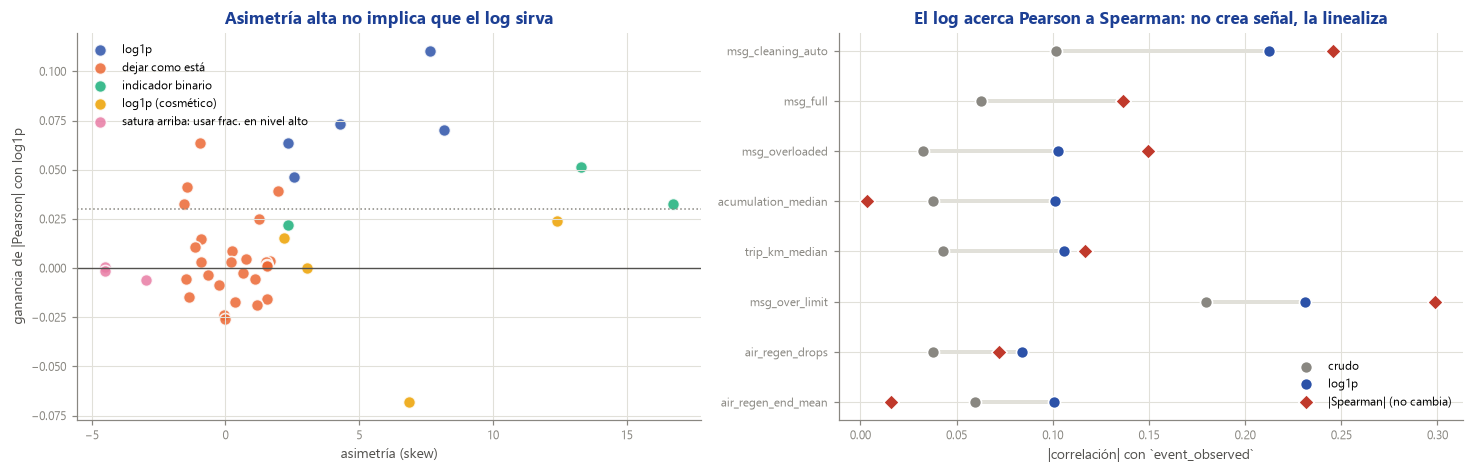

In [41]:
CANDIDATAS = [c for c, fam in FAMILIA.items()
              if fam.startswith(("A ·", "B ·", "C ·", "D ·")) and c in veh.columns]

filas = []
for columna in CANDIDATAS:
    x = veh[columna].dropna()
    if len(x) < 100 or x.nunique() < 3:
        continue
    mediana = x.median()
    p0 = abs(np.corrcoef(x, veh.loc[x.index, "event_observed"])[0, 1])
    log_ok = x.min() >= 0
    p1 = abs(np.corrcoef(np.log1p(x), veh.loc[x.index, "event_observed"])[0, 1]) if log_ok else np.nan
    filas.append({
        "variable": columna,
        "familia": FAMILIA[columna][0],
        "skew": x.skew(),
        "p99/p50": x.quantile(0.99) / mediana if mediana > 0 else np.nan,
        "frac_cero": (x == 0).mean(),
        "rho_spearman": spearmanr(x, veh.loc[x.index, "event_observed"]).statistic,
        "pearson": p0,
        "pearson_log1p": p1,
        "ganancia_log": p1 - p0,
    })
forma = pd.DataFrame(filas)


def receta(fila):
    '''Qué pediría cada distribución. Es una sugerencia medida, no una decisión.'''
    if fila["frac_cero"] >= 0.60:
        return "indicador binario"
    if fila["skew"] > 2 and fila["ganancia_log"] > 0.03:
        return "log1p"
    if fila["skew"] > 2:
        return "log1p (cosmético)"
    if fila["skew"] < -2:
        return "satura arriba: usar frac. en nivel alto"
    return "dejar como está"


forma["sugerencia"] = forma.apply(receta, axis=1)
forma = forma.sort_values("ganancia_log", ascending=False)

print("Ganancia de |Pearson| al pasar a log1p · top 12")
print(forma.head(12)[["variable", "familia", "skew", "frac_cero", "rho_spearman",
                      "pearson", "pearson_log1p", "ganancia_log", "sugerencia"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\nCuántas features caen en cada sugerencia:")
print(forma["sugerencia"].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
ax = axes[0]
sugerencias = list(forma["sugerencia"].unique())
colores = {s: CATEGORICAL[i % len(CATEGORICAL)] for i, s in enumerate(sugerencias)}
for s in sugerencias:
    sub = forma[forma["sugerencia"].eq(s)]
    ax.scatter(sub["skew"], sub["ganancia_log"], s=62, color=colores[s], alpha=0.85,
               edgecolor="white", linewidth=1.1, label=s)
ax.axhline(0, color=INK["secondary"], lw=0.9)
ax.axhline(0.03, color=INK["muted"], lw=1.0, ls=":")
ax.set_xlabel("asimetría (skew)")
ax.set_ylabel("ganancia de |Pearson| con log1p")
ax.set_title("Asimetría alta no implica que el log sirva", color=FORD_BLUE, fontweight="bold")
ax.legend(loc="upper left", fontsize=8)

ax = axes[1]
top = forma.nlargest(8, "ganancia_log").iloc[::-1]
y = np.arange(len(top))
ax.hlines(y, top["pearson"], top["pearson_log1p"], color=INK["grid"], lw=2.6)
ax.scatter(top["pearson"], y, s=62, color=INK["muted"], zorder=3, edgecolor="white",
           linewidth=1.1, label="crudo")
ax.scatter(top["pearson_log1p"], y, s=62, color=BLUE, zorder=3, edgecolor="white",
           linewidth=1.1, label="log1p")
ax.scatter(top["rho_spearman"].abs(), y, s=52, marker="D", color=ALERT_RED, zorder=3,
           edgecolor="white", linewidth=1.0, label="|Spearman| (no cambia)")
ax.set_yticks(y, [v.replace("_per_1000km", "") for v in top["variable"]])
ax.set_xlabel("|correlación| con `event_observed`")
ax.set_title("El log acerca Pearson a Spearman: no crea señal, la linealiza",
             color=FORD_BLUE, fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

¿El valor aporta sobre el indicador binario?


                     variable  frac_cero  rho_valor  rho_pasó/no_pasó  media_sanos  media_evento  el_valor_aporta
          msg_otro_per_1000km      0.990      0.032             0.032        0.000         0.001            0.001
  msg_stopped_auto_per_1000km      0.962      0.079             0.077        0.002         0.004            0.002
      msg_at_limit_per_1000km      0.945      0.215             0.212        0.003         0.123            0.003
msg_stopped_manual_per_1000km      0.910      0.079             0.078        0.007         0.013            0.001
    msg_over_limit_per_1000km      0.876      0.299             0.298        0.124         5.762            0.000
    msg_overloaded_per_1000km      0.369      0.149             0.161        1.527         1.885           -0.012
 msg_cleaning_auto_per_1000km      0.248      0.246             0.215        1.980         3.282            0.031
             regen_per_1000km      0.114      0.317             0.183        1.931     

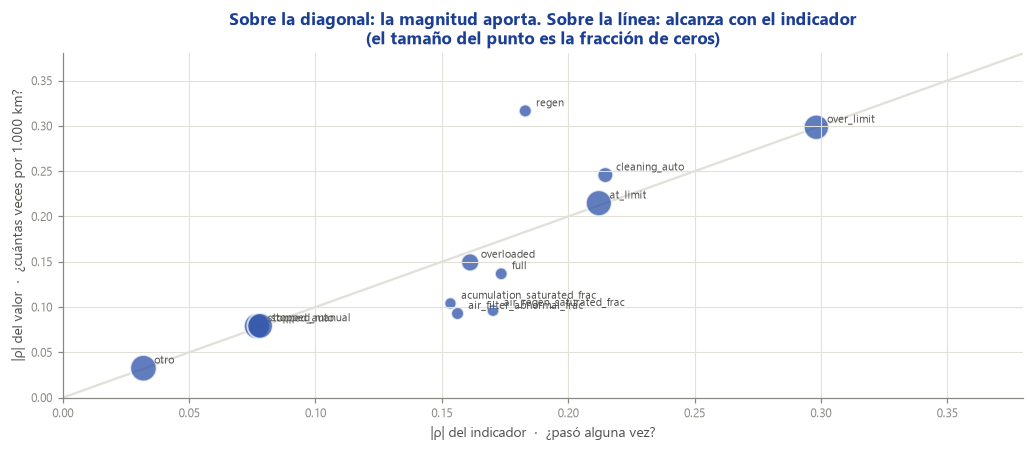

In [42]:
# Zero-inflation: ¿el valor aporta algo por encima del "pasó / no pasó"?
CONTEO = [c for c in veh.columns if c.startswith("msg_")] + [
    "regen_per_1000km", "air_regen_saturated_frac", "acumulation_saturated_frac",
    "air_filter_abnormal_frac"]
filas = []
for columna in CONTEO:
    x = veh[columna].dropna()
    if len(x) < 100:
        continue
    y_ = veh.loc[x.index, "event_observed"]
    binaria = (x > 0).astype(int)
    filas.append({
        "variable": columna,
        "frac_cero": (x == 0).mean(),
        "rho_valor": spearmanr(x, y_).statistic,
        "rho_pasó/no_pasó": spearmanr(binaria, y_).statistic if binaria.nunique() > 1 else np.nan,
        "media_sanos": veh.loc[veh["event_observed"].eq(0), columna].mean(),
        "media_evento": veh.loc[veh["event_observed"].eq(1), columna].mean(),
    })
ceros = pd.DataFrame(filas)
ceros["el_valor_aporta"] = (ceros["rho_valor"].abs() - ceros["rho_pasó/no_pasó"].abs()).round(3)
ceros = ceros.sort_values("frac_cero", ascending=False)
print("¿El valor aporta sobre el indicador binario?")
print(ceros.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
sub = ceros.dropna(subset=["rho_pasó/no_pasó"])
ax.scatter(sub["rho_pasó/no_pasó"].abs(), sub["rho_valor"].abs(),
           s=40 + 260 * sub["frac_cero"], color=BLUE, alpha=0.75, edgecolor="white", linewidth=1.2)
for _, fila in sub.iterrows():
    ax.annotate(fila["variable"].replace("_per_1000km", "").replace("msg_", ""),
                (abs(fila["rho_pasó/no_pasó"]), abs(fila["rho_valor"])),
                textcoords="offset points", xytext=(7, 3), fontsize=7.5, color=INK["secondary"])
lim = 0.38
ax.plot([0, lim], [0, lim], color=INK["grid"], lw=1.5, zorder=0)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("|ρ| del indicador  ·  ¿pasó alguna vez?")
ax.set_ylabel("|ρ| del valor  ·  ¿cuántas veces por 1.000 km?")
ax.set_title("Sobre la diagonal: la magnitud aporta. Sobre la línea: alcanza con el indicador\n"
             "(el tamaño del punto es la fracción de ceros)", color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

**Cuatro lecturas, y ninguna es una decisión: son el insumo para tomarla.**

**1 · El log sirve donde hay masa en la cola, y solo para modelos lineales.** La
regla de arriba marca cinco candidatas con `log1p`, y las tres primeras son tasas de
la familia D: `msg_cleaning_auto_per_1000km` (|r| 0,102 → 0,212),
`msg_full_per_1000km` (0,063 → 0,136) y `msg_overloaded_per_1000km`
(0,032 → 0,103). En los tres casos el `log1p` **acerca Pearson a Spearman**: no crea
señal, la vuelve lineal. El corolario es que **para LightGBM el log no cambia nada**
—el árbol ya usa el orden— y que el lugar donde se paga es la regresión logística.

Caso aparte, `regen_per_1000km`: la regla lo deja en "dejar como está" porque su
skew es 1,97 y el umbral está en 2, pero gana 0,039 (0,265 → 0,304) y es la feature
más correlacionada del EDA. Es un borde del umbral, no una conclusión: entra a la
lista de candidatas igual.

**2 · Asimetría alta no implica que el log sirva.** `speed_mean` tiene skew 12,4 y
gana 0,024; `trip_odo_min`, skew 10,0 y no gana nada. Ahí la cola son outliers de
medición (§5.3: velocidades de 135.600 km/h), no una distribución multiplicativa, y
lo que corresponde es **recortar por cuantil, no transformar**.

**3 · Y una ganancia de Pearson sin Spearman detrás es ruido.**
`acumulation_median` aparece cuarta en la tabla con +0,064 de ganancia… y su ρ de
Spearman con la etiqueta es **−0,003**. No hay señal que linealizar: el log le
cambió la forma a una variable que no separa cohortes, y el |Pearson| subió por
azar. La columna `rho_spearman` es la que hay que mirar antes de emocionarse con
`ganancia_log`. Lo mismo vale para `acumulation_mean` y `air_regen_end_mean`.

**4 · Tres features de severidad no son continuas, son indicadores.**
`msg_at_limit_per_1000km` es **94,5% ceros** y `msg_over_limit_per_1000km`
**87,6%**, y en los dos casos el ρ del indicador binario es idéntico al del valor
(0,212 vs 0,215 · 0,298 vs 0,299): **toda la señal está en "pasó alguna vez", nada
en "cuántas veces"**. Al revés en `regen_per_1000km`, donde el valor aporta 0,317
contra 0,183 del indicador: ahí la magnitud es lo que importa y binarizarla tiraría
casi la mitad de la señal. Y hay un tercer grupo —`air_regen_saturated_frac`,
`acumulation_saturated_frac`, `msg_full_per_1000km`— donde el indicador binario
**supera** al valor (0,170 vs 0,096 · 0,153 vs 0,104 · 0,173 vs 0,137): saturar
alguna vez discrimina más que cuánto tiempo se estuvo saturado.

> **Advertencia sobre la potencia de esta sección.** Todo esto se mide sobre 290
> vehículos con 60 eventos. Una diferencia de |ρ| menor a ~0,08 no es distinguible
> del ruido a este tamaño de muestra, así que la tabla sirve para **ordenar
> candidatas**, no para descartar ninguna. Y se mide sobre el **historial completo
> a nivel vehículo**, que no es el grano en el que van a vivir las features: la
> decisión final se toma con el panel armado y con la comparación out-of-fold.

## 8 · Análisis temporal

El eje de km es el del contrato, pero el calendario dice cómo se recolectaron los
datos, y eso explica varios de los sesgos de §7.

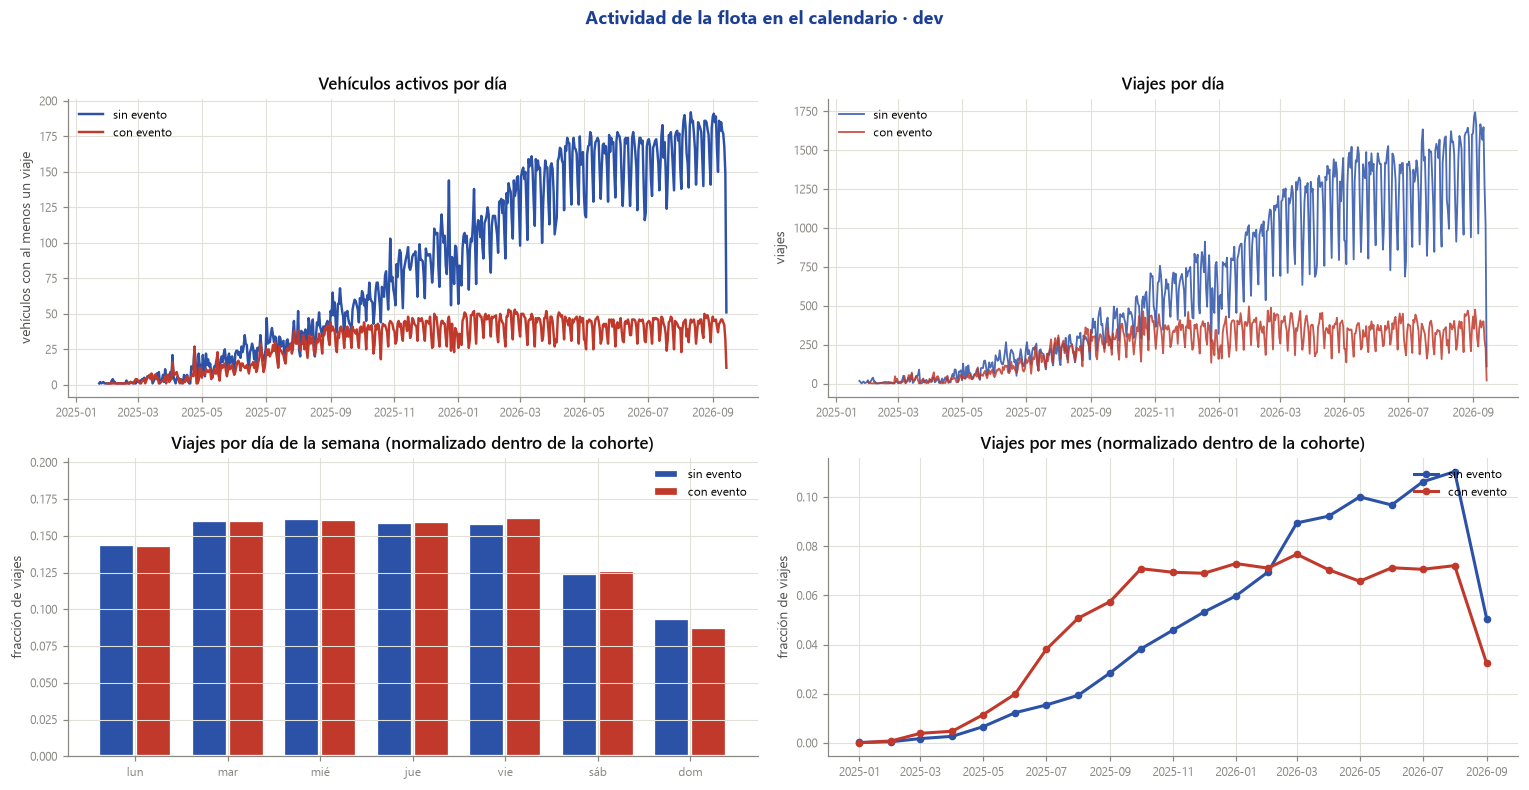

In [43]:
diario = cache["trips_daily_dev"].copy()
diario["date"] = pd.to_datetime(diario["date"])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

ax = axes[0, 0]
for flag in COHORT_ORDER:
    side = diario[diario["event_observed"].eq(flag)].sort_values("date")
    ax.plot(side["date"], side["n_vehicles"], color=COHORT_COLORS[flag], lw=1.6,
            label=COHORT_LABELS[flag])
ax.set_title("Vehículos activos por día")
ax.set_ylabel("vehículos con al menos un viaje")
ax.legend(loc="upper left")

ax = axes[0, 1]
for flag in COHORT_ORDER:
    side = diario[diario["event_observed"].eq(flag)].sort_values("date")
    ax.plot(side["date"], side["n_trips"], color=COHORT_COLORS[flag], lw=1.2, alpha=0.85,
            label=COHORT_LABELS[flag])
ax.set_title("Viajes por día")
ax.set_ylabel("viajes")
ax.legend(loc="upper left")

ax = axes[1, 0]
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
semana = diario.groupby(["weekday", "event_observed"], observed=True)["n_trips"].sum().unstack()
semana = semana / semana.sum()
x = np.arange(7)
for i, flag in enumerate(COHORT_ORDER):
    if flag not in semana.columns:
        continue
    ax.bar(x + (i - 0.5) * 0.4, semana[flag], 0.38, color=COHORT_COLORS[flag],
           label=COHORT_LABELS[flag], edgecolor="white", linewidth=1.5)
ax.set_xticks(x, DIAS)
ax.set_title("Viajes por día de la semana (normalizado dentro de la cohorte)")
ax.set_ylabel("fracción de viajes")
ax.set_ylim(0, semana.to_numpy().max() * 1.25)
ax.legend(loc="upper right")

ax = axes[1, 1]
mensual = diario.groupby(["month", "event_observed"], observed=True)["n_trips"].sum().unstack()
mensual = mensual / mensual.sum()
for flag in COHORT_ORDER:
    if flag not in mensual.columns:
        continue
    ax.plot(mensual.index, mensual[flag], color=COHORT_COLORS[flag], lw=2, marker="o", ms=4,
            label=COHORT_LABELS[flag])
ax.set_title("Viajes por mes (normalizado dentro de la cohorte)")
ax.set_ylabel("fracción de viajes")
ax.legend(loc="upper right")

fig.suptitle("Actividad de la flota en el calendario · dev", y=1.02, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

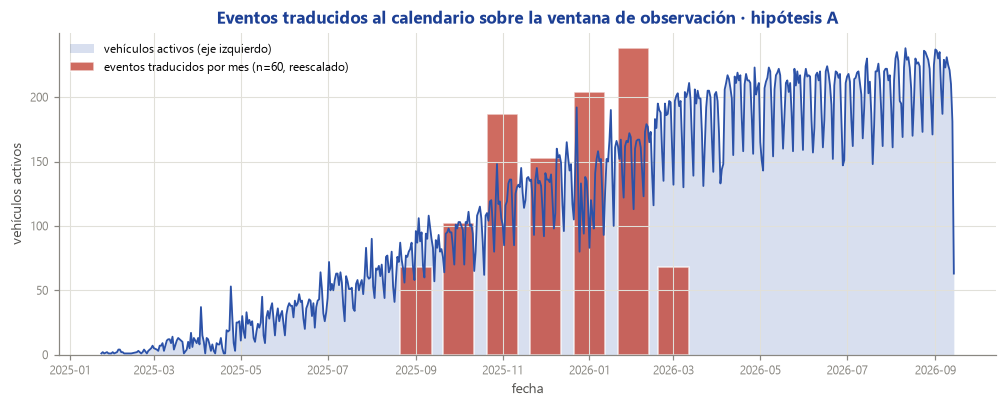

ventana de viajes observada: 2025-01-23 → 2026-09-14
eventos traducidos (A)     : 2025-09-03 → 2026-03-11
eventos fuera de la ventana: 0


In [44]:
# Distribución calendario de los eventos traducidos, contra la ventana de observación.
fig, ax = plt.subplots(figsize=(11, 3.8))
activos = diario.groupby("date")["n_vehicles"].sum()
ax.fill_between(activos.index, activos.to_numpy(), color=BLUE, alpha=0.18, lw=0,
                label="vehículos activos (eje izquierdo)")
ax.plot(activos.index, activos.to_numpy(), color=BLUE, lw=1.2)
ax.set_ylabel("vehículos activos")
ax.set_xlabel("fecha")

fechas_evento = pd.to_datetime(eventos["event_date"]).dropna()
conteo = fechas_evento.dt.tz_localize(None).dt.to_period("M").value_counts().sort_index()
escala = activos.max() / max(conteo.max(), 1)
ax.bar([p.to_timestamp() for p in conteo.index], conteo.to_numpy() * escala, width=22,
       color=ALERT_RED, alpha=0.75, edgecolor="white", linewidth=1.0,
       label=f"eventos traducidos por mes (n={len(fechas_evento)}, reescalado)")
ax.set_title("Eventos traducidos al calendario sobre la ventana de observación · hipótesis A",
             color=FORD_BLUE, fontweight="bold")
ax.legend(loc="upper left")
plt.show()

print(f"ventana de viajes observada: {diario['date'].min():%Y-%m-%d} → {diario['date'].max():%Y-%m-%d}")
print(f"eventos traducidos (A)     : {fechas_evento.min():%Y-%m-%d} → {fechas_evento.max():%Y-%m-%d}")
print(f"eventos fuera de la ventana: {int((fechas_evento < diario['date'].min()).sum() + (fechas_evento > diario['date'].max()).sum())}")

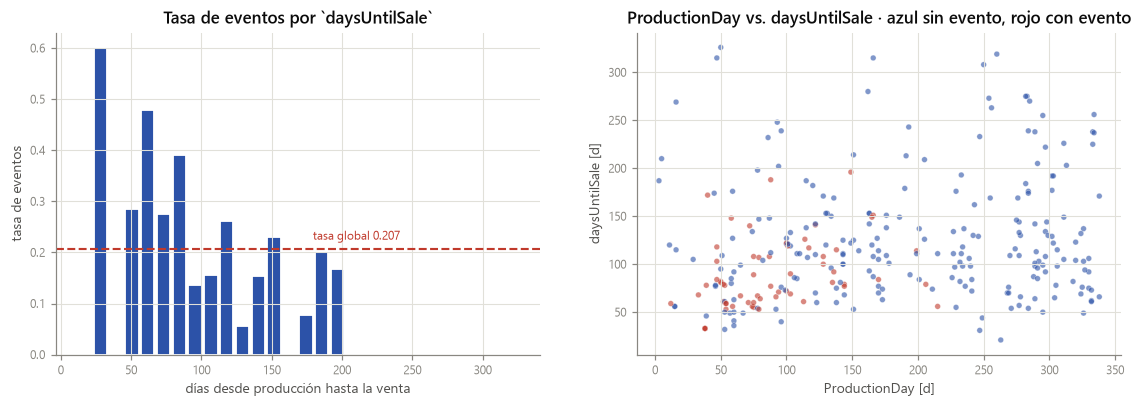

In [45]:
# `daysUntilSale` contra el evento, ya sabiendo lo de §3.3.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax = axes[0]
bins = np.linspace(0, veh["static_daysUntilSale"].max(), 30)
tasa = (veh.assign(b=pd.cut(veh["static_daysUntilSale"], bins))
        .groupby("b", observed=True)
        .agg(n=("event_observed", "size"), tasa=("event_observed", "mean")))
centros = [interv.mid for interv in tasa.index]
ax.bar(centros, tasa["tasa"], width=(bins[1] - bins[0]) * 0.85, color=BLUE, edgecolor="white",
       linewidth=1.2)
ax.axhline(veh["event_observed"].mean(), color=ALERT_RED, lw=1.4, ls="--")
ax.annotate(f"tasa global {veh['event_observed'].mean():.3f}",
            xy=(bins[-1] * 0.55, veh["event_observed"].mean()), xytext=(0, 6),
            textcoords="offset points", color=ALERT_RED, fontsize=8)
ax.set_title("Tasa de eventos por `daysUntilSale`")
ax.set_xlabel("días desde producción hasta la venta")
ax.set_ylabel("tasa de eventos")

ax = axes[1]
ax.scatter(veh["static_ProductionDay"], veh["static_daysUntilSale"],
           c=[COHORT_COLORS[int(f)] for f in veh["event_observed"]], s=14, alpha=0.6,
           edgecolor="white", linewidth=0.3)
ax.set_title("ProductionDay vs. daysUntilSale · azul sin evento, rojo con evento")
ax.set_xlabel("ProductionDay [d]")
ax.set_ylabel("daysUntilSale [d]")
plt.show()

## 9 · Factibilidad de las features del plan §4

Cruce entre lo que el plan propone (`plan-implementacion-ford.md` §4, con los
nombres ya reservados en `scripts/make_dummy.py::FEATURE_SPECS`) y lo que existe en
los CSV reales.

In [46]:
# El cruce vive en `scripts/build_eda_cache.py` (`PLAN_FEATURE_REQUIREMENTS` +
# `COLUMN_SUBSTITUTES`), así el dashboard muestra exactamente la misma tabla.
factibilidad = feature_feasibility(CONFIG)

print(factibilidad["veredicto"].value_counts().to_string())
print()
factibilidad[["feature", "familia", "columna_requerida", "veredicto", "sustituto"]]

veredicto
se puede construir                                                 21
se puede construir (con sustituto)                                  4
BLOQUEADA · no hay dato                                             4
parcial con sustituto                                               1
REQUIERE REDEFINIR · la columna está pero el contenido no sirve     1



,feature,familia,columna_requerida,veredicto,sustituto
0,feat_short_trip_frac_5km,A,OdometerTripStart/End,se puede construir,
1,feat_trips_below_regime_temp_frac,A,EngineTemperatureMax,se puede construir,
2,feat_engine_temp_avg_median,A,EngineTemperatureAvg,se puede construir,
3,feat_engine_temp_amplitude_mean,A,EngineTemperatureMin/Max,se puede construir,
4,feat_coolant_temp_end_mean,A,CoolantTemperatureEnd,se puede construir,
5,feat_trip_distance_median_km,A,OdometerTripStart/End,se puede construir,
6,feat_trip_distance_p25_km,A,OdometerTripStart/End,se puede construir,
7,feat_dpf_end_slope_per_1000km,B,DieselParticulateFilterEnd,se puede construir (con sustituto),AirRegenerationEnd (= signals.Acumulation en e...
8,feat_dpf_end_mean,B,DieselParticulateFilterEnd,se puede construir (con sustituto),AirRegenerationEnd (= signals.Acumulation en e...
9,feat_dpf_end_max,B,DieselParticulateFilterEnd,se puede construir (con sustituto),AirRegenerationEnd (= signals.Acumulation en e...


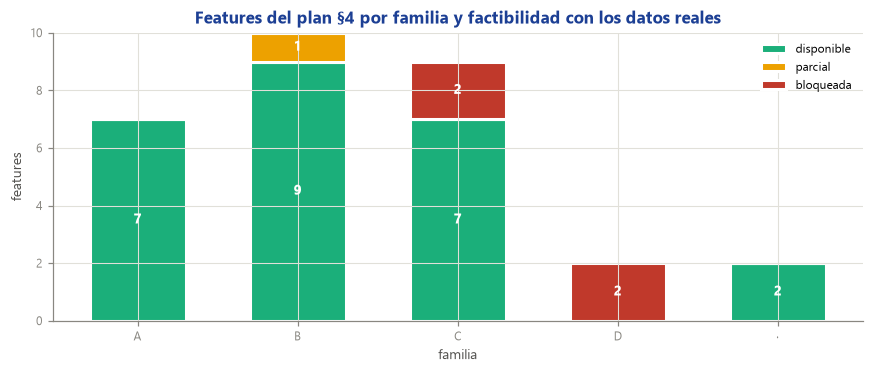

BLOQUEADAS (la columna no existe en el CSV bajo ningún nombre):
                          feature familia                    columna_requerida
            feat_elevation_mean_m       C       VehicleElevationRangeStart/End
           feat_elevation_range_m       C       VehicleElevationRangeStart/End
          feat_tire_pressure_mean       D TirePressure{LF,RF,LR,RR}{Start,End}
feat_tire_pressure_below_thr_frac       D TirePressure{LF,RF,LR,RR}{Start,End}


In [47]:
fig, ax = plt.subplots(figsize=(9.5, 3.4))
resumen = (factibilidad.groupby(["familia", "estado"]).size().unstack(fill_value=0)
           .reindex(columns=["disponible", "parcial", "bloqueada"], fill_value=0))
colores = {"disponible": CATEGORICAL[2], "parcial": CATEGORICAL[3], "bloqueada": ALERT_RED}
abajo = np.zeros(len(resumen))
for estado in resumen.columns:
    ax.bar(resumen.index, resumen[estado], 0.6, bottom=abajo, color=colores[estado], label=estado,
           edgecolor="white", linewidth=2)
    for x, (valor, base) in enumerate(zip(resumen[estado], abajo)):
        if valor:
            ax.text(x, base + valor / 2, str(int(valor)), ha="center", va="center", color="white",
                    fontsize=9, fontweight="bold")
    abajo = abajo + resumen[estado].to_numpy()
ax.set_title("Features del plan §4 por familia y factibilidad con los datos reales", color=FORD_BLUE,
             fontweight="bold")
ax.set_ylabel("features")
ax.set_xlabel("familia")
ax.legend(loc="upper right")
plt.show()

print("BLOQUEADAS (la columna no existe en el CSV bajo ningún nombre):")
print(factibilidad.loc[factibilidad["veredicto"].str.startswith("BLOQUEADA"),
                       ["feature", "familia", "columna_requerida"]].to_string(index=False))

**Resultado.**

- **Familias A y C (menos elevación), y D (menos presión de neumáticos): completas.**
  Todas sus columnas existen en `trips`.
- **Familia B: completa también**, gracias a §6.4. `feat_dpf_*` se construye con
  `AirRegenerationStart/End` en vez de `DieselParticulateFilter*`.
  `feat_manual_regen_per_1000km` queda parcial: el hollín de regeneración manual no
  está, pero los niveles `Cleanning/Stopped Cleanning Manually Air Filter` de
  `Message`/`AirFilter*` marcan el evento (son raros: los ven 31 y 4 vehículos de
  dev respectivamente, así que como tasa va a ser casi siempre cero).
- **`feat_oil_life_drop_per_1000km` hay que redefinirla** (§5.3): la columna existe
  y está completa, pero su delta intra-viaje es exactamente cero en el 100% de los
  viajes.
- **Bloqueadas, sin sustituto posible: 4 features.** `feat_elevation_mean_m` y
  `feat_elevation_range_m` (familia C) y `feat_tire_pressure_mean` y
  `feat_tire_pressure_below_thr_frac` (familia D). Las columnas de elevación, GPS y
  presión de neumáticos **no están en el archivo**, y no hay nada que las
  aproxime: sin GPS tampoco se puede inferir altitud.

La elevación era, según el plan, la variable "ligada directamente al ingreso de
oxígeno que menciona el título del desafío". Ese ángulo no se puede explorar con
estos datos.

## 10 · Síntesis para quien implemente F2

### Lo que cambió respecto de la versión anterior de este EDA

0. **El bloqueante se cerró, y costó 717 vehículos.** El universo del estudio pasó
   de 1081 a **364** (290 dev / 74 test), y la tasa de eventos de 0,338 a **0,207**.
   Salieron los 284 positivos cuya `IdentificationDate` es igual a `daysUntilSale`
   —el evento queda a 13 km de odómetro, sin historial— y, con ellos, los mercados
   donde ningún evento es observable, porque dejar sus sanos adentro habría sido
   selección sobre el resultado (§3.3). Queda escrito en `decisiones.md`.

### Lo que desbloquea

1. **El evento ya se puede ubicar en el eje de km** (§3.4). Mediana de 7.987 km con
   el **39% del historial de viajes por delante**, y 58 de 60 eventos interpolados
   entre dos viajes reales. Hay ventana W que agregar y gap G que blanquear: **W, G,
   H y Δ se pueden definir**, que es lo que estaba trabado.
2. **El DPF existe, con otro nombre y en las dos tablas** (§6.4).
   `trips.AirRegenerationStart/End` coincide con `signals.Acumulation` en el 99,8%
   de los pares alineados, y `trips.AirFilterStart/End` con `signals.Message` en el
   99,98%. La familia B se puede construir entera y a nivel viaje.
3. **La familia B anticipa, y ahora hay evidencia de que anticipa** (§7.4). Al
   truncar al primer 70% del recorrido, `regen_per_1000km` retiene el **90%** de su
   correlación y `msg_over_limit_per_1000km` el **101%**, mientras que
   `air_regen_saturated_frac` retiene el 58% y `acumulation_high_frac` el 18%. La
   frecuencia de regeneración es régimen de uso; el nivel de saturación es estado
   cercano al evento. **Priorizar frecuencias sobre niveles.**
4. **El anclaje temporal se sostiene** (§3.1): IQR de 0 días también en el universo
   recortado. La mecánica de traducción funciona.
5. **Los dos mercados que quedan se pueden juntar** (§3.3b): 9 de 10 variables del
   ranking apuntan en la misma dirección en CNTRY_3 y en CNTRY_4.

### Lo que hay que sacar o auditar antes de entrenar

6. **`static_ProductionDay` fuera del set base** (§7.3). Es la variable más
   correlacionada de todo el EDA (ρ = −0,435), la tasa de eventos por quintil va de
   0,459 a **0,000**, y contra `span_days` da ρ = −0,933: es la ventana de
   observación, no el vehículo. Mismo criterio con el que se sacó `Engine`.
7. **Sacar `Engine` no alcanza: `ModelSeries` lleva la misma información** (§2). El
   cruce es casi diagonal —`ENG_1`↔`MODEL_4`, `ENG_2`↔`MODEL_1`/`MODEL_2`,
   `ENG_3`↔`MODEL_3`— y en el universo recortado `MODEL_3` tiene 0 eventos de 24 y
   `MODEL_4` 2 de 91. Hay que decidir explícitamente si `ModelSeries` entra.
8. **`static_daysUntilSale` ya no es la etiqueta disfrazada, pero se audita igual**
   (§7.3): ρ = −0,261. Ablación en otro YAML, no exclusión de oficio.
9. **Las variables de cobertura no son features** (§7.2): `span_days` (0,361),
   `n_signals` (0,279), `n_trips` (0,260), `km_observed` (0,226). Es exposición.
   `sampling.match_healthy_cut_distribution` de `panel_v1.yaml` existe para esto.
10. **Las tasas absolutas arrastran el nivel del mercado** (§3.3b).
    `msg_full_per_1000km` es **5,45x** más alto en CNTRY_4 que en CNTRY_3. Con 191
    vehículos de uno y 99 del otro, el modelo puede aprender el país. Vale medir una
    variante normalizada dentro del mercado, ajustada en el train de cada fold.

### Lo que hay que manejar

11. **Dos de los 60 eventos pasan el filtro y siguen sin historial** (§3.4):
    `VEH_0056` y `VEH_0499`, con delta de 2 y 1 día y el evento a 5 y 8 km.
    `sampling.min_trips_in_window` los va a descartar; conviene que sea explícito.
12. **Hay 15.636 km de mediana DESPUÉS del evento** (§3.4). El evento es una
    identificación, no una baja. Ese tramo no puede entrar en ninguna ventana.
13. **Cuatro features del plan quedan sin datos y una está mal especificada** (§9,
    §5.3): elevación (×2, familia C) y presión de neumáticos (×2, familia D) no
    existen en el CSV bajo ningún nombre. Y `feat_oil_life_drop_per_1000km` se
    redefine como pendiente contra odómetro: el delta intra-viaje es cero siempre.
14. **El odómetro nulo de `signals` dejó de ser un problema** (§4): de 11,15% sobre
    los 1081 a **0,009%** sobre los 290, con los 290 por debajo del 1%. Los cuatro
    vehículos que concentraban el problema estaban en los mercados descartados. En
    cambio `KilometerPerHour` empeoró: 35,4% de nulos contra 32,5%.
15. **`signals` trae ~1,1% de filas exactamente repetidas** que no son clones. Toda
    tasa por 1.000 km sale inflada si no se deduplica. El cache ya lo hace.
16. **Feature engineering: hay diagnóstico, no hay decisión** (§7.5). Tres tasas de
    familia D ganan con `log1p` **para modelos lineales** (Spearman no cambia, así
    que a LightGBM le da igual); dos features de severidad son 88-95% ceros y ahí el
    indicador binario empata al valor; y tres features de saturación rinden **más**
    como indicador que como magnitud. Hay también tres ganancias de Pearson que son
    ruido: suben sin que Spearman las acompañe. Nada de esto se aplicó: se decide con
    el panel armado.

### Lo que NO se decidió acá

W, G, H, Δ, el umbral de operación y qué features entran al set base. Nada de eso
sale de un notebook: sale de `configs/` y se registra en `docs/memoria/decisiones.md`.

In [48]:
# Cierre: la guarda, una vez más, sobre todo lo que se tocó.
print("Verificación final de la restricción dev-only:\n")
for nombre, tabla in cache.items():
    if isinstance(tabla, pd.DataFrame) and "vehicle_id" in tabla.columns:
        check_dev_only(tabla, nombre)
check_dev_only(veh, "vehicle_matrix")
check_dev_only(eventos, "eventos (con evento)")
check_dev_only(severidad, "severity + etiqueta")
check_dev_only(alineado, "alineación trips↔signals")

print(f"\nvehículos de test declarados en el holdout : {len(TEST_VEHICLES)}")
print(f"vehículos de test tocados en el notebook   : 0")
print(f"universo efectivo del EDA                  : {veh['vehicle_id'].nunique()} de {len(DEV_VEHICLES)} de dev")

Verificación final de la restricción dev-only:

  [ok] vehicles_dev                  290 filas ·  290 vehículos · 0 de test
  [ok] trips_agg_dev                 290 filas ·  290 vehículos · 0 de test
  [ok] signals_agg_dev               290 filas ·  290 vehículos · 0 de test
  [ok] severity_scopes_dev           870 filas ·  290 vehículos · 0 de test
  [ok] message_counts_dev           3003 filas ·  290 vehículos · 0 de test
  [ok] airfilter_counts_dev         1634 filas ·  290 vehículos · 0 de test
  [ok] trips_sample_dev           250000 filas ·  290 vehículos · 0 de test
  [ok] signals_sample_dev         250000 filas ·  290 vehículos · 0 de test
  [ok] probe_trips_dev             14462 filas ·    8 vehículos · 0 de test
  [ok] probe_signals_dev           57945 filas ·    8 vehículos · 0 de test
  [ok] vehicle_matrix                290 filas ·  290 vehículos · 0 de test
  [ok] eventos (con evento)           60 filas ·   60 vehículos · 0 de test
  [ok] severity + etiqueta           870